# Tentative Title

## Team Members: Altair Aguelo (A17435920), Ashton Bothun (A17388030), Gavin Guyal (A17514923), Jason Tang (A17438070)

# Introduction & Tasks

## Tasks
> We will be working on symbolic, unconditioned generation, and symbolic, conditioned generation. We will be training a model on a training set of video game music data. For unconditioned generation of music, we will train a model that learns and samples from a music distribution. For conditioned generation, we will give inputs based on things like harmonization, chords, and transcriptions in order to point learning in the model toward a certain direction.

# 1. Exploratory Analysis, Data Collection, Pre-Processing, and Discussion

## Context
> Our dataset comes from user and dataset owner, Hansespinosa2 from Kaggle.com, in which they had originally scraped this data from the ninsheetmusic.org website. The data from ninsheetmusic.org was made my musical experts who created transcriptions to produce sheet music and midi files. The purpose of the dataset is to be a collection of about 5,000 MIDI files of many various video games, all of which are entirely piano transcriptions. The collection method was the scraping of ninsheetmusic.org from early 2024. Per the dataset owner's request, the primary credit goes to the composers and producers behind the original video game music as well as the transcription experts who transcribed the songs into sheet music and MIDI files, which we will be utilizing.

## Discussion

## Code

In [3]:
import pretty_midi
import pandas as pd
import glob
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

In [4]:
def estimate_key_and_mode(pitch_class_hist):
    """
    Uses the Krumhansl-Schmuckler algorithm to estimate the key and tonality (Major/Minor)
    from a 12-element pitch class histogram.
    """
    if sum(pitch_class_hist) == 0:
        return "Unknown", "Unknown"

    # Krumhansl-Schmuckler key profiles
    major_profile = [6.35, 2.23, 3.48, 2.33, 4.38, 4.09, 2.52, 5.19, 2.39, 3.66, 2.29, 2.88]
    minor_profile = [6.33, 2.68, 3.52, 5.38, 2.60, 3.53, 2.54, 4.75, 3.98, 2.69, 3.34, 3.17]
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

    max_corr = -1.0
    best_key = "Unknown"
    best_mode = "Unknown"

    # Test the histogram against all 12 possible shifts (keys)
    for i in range(12):
        shifted_major = np.roll(major_profile, i)
        shifted_minor = np.roll(minor_profile, i)

        # Calculate Pearson correlation
        corr_major = np.corrcoef(pitch_class_hist, shifted_major)[0, 1]
        corr_minor = np.corrcoef(pitch_class_hist, shifted_minor)[0, 1]

        if corr_major > max_corr:
            max_corr = corr_major
            best_key = note_names[i]
            best_mode = "Major"

        if corr_minor > max_corr:
            max_corr = corr_minor
            best_key = note_names[i]
            best_mode = "Minor"

    return best_key, best_mode

In [ ]:
def analyze_tracks_and_vocab(file_path):
    try:
        pm = pretty_midi.PrettyMIDI(file_path)
    except Exception:
        # Returns None if a fan-made MIDI file is corrupt
        return None
    
    duration = pm.get_end_time()
    if duration == 0:
        return None

    # Core statistical accumulators
    all_pitches = []
    all_durations = []
    start_times = []
    all_velocities = []
    # Advanced feature accumulators
    track_avg_intervals = []
    track_programs = []
    
    melody_tracks_count = 0
    harmony_tracks_count = 0
    
    # Analyze individual tracks (instruments)
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue
            
        notes = instrument.notes
        if len(notes) == 0:
            continue
            
        track_pitches = [n.pitch for n in notes]
        track_start_times = [n.start for n in notes]
        track_durations = [round(n.end - n.start, 3) for n in notes]
        track_velocities = [n.velocity for n in notes]
        
        all_pitches.extend(track_pitches)
        all_durations.extend(track_durations)
        start_times.extend(track_start_times)
        all_velocities.extend(track_velocities)
        
        
        # Track what instruments are being used
        track_programs.append(instrument.program)
        
        # Heuristic for Task 2 Track Separation:
        time_counts = Counter(track_start_times)
        avg_track_polyphony = np.mean(list(time_counts.values()))
        
        if avg_track_polyphony < 1.1:
            melody_tracks_count += 1
        else:
            harmony_tracks_count += 1
            
        # Melodic Volatility (Average Interval Jump)
        if len(track_pitches) > 1:
            intervals = np.diff(track_pitches)
            avg_interval = np.mean(np.abs(intervals))
            track_avg_intervals.append(avg_interval)

    if not all_pitches:
        return None

    # Calculate overall polyphony across the entire song
    overall_time_counts = Counter(start_times)
    avg_overall_polyphony = np.mean(list(overall_time_counts.values()))

    # --- Calculate Global Advanced Features ---
    rhythmic_density = len(all_pitches) / duration
    pitch_range = max(all_pitches) - min(all_pitches)
    avg_interval_jump = np.mean(track_avg_intervals) if track_avg_intervals else 0
    
    pitch_class_hist = pm.get_pitch_class_histogram()
    
    tempi = pm.get_tempo_changes()[1]
    avg_tempo = np.mean(tempi) if len(tempi) > 0 else 120.0
    
    duration_variance = np.std(all_durations) if len(all_durations) > 0 else 0
    
    pitch_class_hist = pm.get_pitch_class_histogram()
    estimated_key, estimated_mode = estimate_key_and_mode(pitch_class_hist)
    # Rest Counting (Zip times and durations together to accurately find gaps)
    note_events = sorted(zip(start_times, all_durations), key=lambda x: x[0])
    rests_count = sum(1 for i in range(1, len(note_events)) 
                      if note_events[i][0] - (note_events[i-1][0] + note_events[i-1][1]) > 0.05)

    return {
        "game_name": os.path.basename(os.path.dirname(file_path)),
        "song_name": os.path.basename(file_path),
        "duration": round(duration, 2),
        "total_notes": len(all_pitches),
        "unique_pitches_in_file": len(set(all_pitches)),
        "min_pitch": min(all_pitches),
        "max_pitch": max(all_pitches),
        "unique_durations_in_file": len(set(all_durations)),
        "key": estimated_key,        # E.g., 'C', 'F#'
        "tonality": estimated_mode,  # E.g., 'Major', 'Minor'
        
        # --- Advanced Features ---
        "avg_tempo": round(avg_tempo, 2),
        "rhythmic_density": round(rhythmic_density, 2),
        "duration_variance": round(duration_variance, 3),
        "pitch_range": pitch_range,
        "avg_interval_jump": round(avg_interval_jump, 2),
        "rests_count": rests_count,
        "pitch_class_hist": pitch_class_hist,
        "instrument_programs": track_programs,
        
        "avg_polyphony": round(avg_overall_polyphony, 2),
        "melody_tracks": melody_tracks_count,
        "harmony_tracks": harmony_tracks_count,
        "all_pitches": all_pitches,
        "all_durations": all_durations,
        "all_start_times": start_times,
        "all_velocities": all_velocities
    }

# ---------------------------------------------------------
# Execution & Table Generation
# ---------------------------------------------------------

# Replace with your actual list of paths if already loaded
midi_files = glob.glob('./nintendo_midi_data/**/*.mid', recursive=True)

# Run pipeline over your dataset
processed_data = []
corrupt_count = 0

print(f"Starting processing on {len(midi_files)} files...")

for f in midi_files:
    metrics = analyze_tracks_and_vocab(f)
    if len(processed_data) % 1000 == 0 and len(processed_data) > 0:
        print(f"Processed {len(processed_data)} files...")
        
    if metrics is not None:
        processed_data.append(metrics)
    else:
        corrupt_count += 1

df = pd.DataFrame(processed_data)

# Flatten master lists to calculate global vocabularies
global_pitches = [pitch for song in df['all_pitches'] for pitch in song]
global_durations = [dur for song in df['all_durations'] for dur in song]

print(f"--- PIPELINE PROCESSING COMPLETE ---")
print(f"Successfully loaded: {len(df)} | Corrupt/Skipped: {corrupt_count}\n")

Starting processing on 4970 files...


c:\Users\altai\anaconda3\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Processed 1000 files...
Processed 2000 files...
Processed 3000 files...
Processed 4000 files...
--- PIPELINE PROCESSING COMPLETE ---
Successfully loaded: 4960 | Corrupt/Skipped: 10



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Print the top 5 rows to verify the game_name and song_name extraction worked
display(df.head())

# 2. Generate a statistical summary of the numerical columns
summary_stats = df[['duration', 'total_notes', 'unique_pitches_in_file', 'avg_polyphony']].describe().round(2)
display(summary_stats)

,game_name,song_name,duration,total_notes,unique_pitches_in_file,min_pitch,max_pitch,unique_durations_in_file,key,tonality,...,rests_count,pitch_class_hist,instrument_programs,avg_polyphony,melody_tracks,harmony_tracks,all_pitches,all_durations,all_start_times,all_velocities
0,Halo2,TheLastSpartan.mid,129.00,390,39,31,91,18,G,Major,...,47,"[0.05384615384615385, 0.010256410256410256, 0....",[0],1.64,0,1,"[62, 72, 77, 80, 62, 80, 78, 69, 74, 74, 77, 8...","[4.125, 3.0, 3.0, 3.0, 0.375, 0.75, 1.5, 2.25,...","[0.0, 1.500008, 1.500008, 1.500008, 4.125022, ...","[64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 6..."
1,Halo2,Unforgotten.mid,120.31,238,29,27,82,47,F,Minor,...,0,"[0.09663865546218488, 0.0546218487394958, 0.03...",[1],1.43,0,1,"[56, 56, 41, 56, 63, 37, 58, 58, 39, 56, 56, 4...","[2.143, 2.136, 2.136, 2.14, 2.14, 2.14, 4.287,...","[0.0, 0.006978369140624999, 0.0069783691406249...","[49, 49, 49, 53, 67, 59, 49, 77, 74, 49, 25, 2..."
2,HaloCombatEvolved,Halo.mid,166.05,914,35,28,85,87,E,Minor,...,5,"[0.02516411378555799, 0.0437636761487965, 0.07...",[1],1.46,0,1,"[52, 54, 55, 54, 57, 55, 54, 52, 40, 47, 59, 6...","[1.239, 0.643, 0.657, 0.676, 0.694, 0.712, 1.4...","[1.2039486962890626, 2.443715973632813, 3.0871...","[49, 49, 49, 49, 49, 49, 49, 49, 45, 56, 49, 4..."
3,HaloCombatEvolved,OnaPaleHorse.mid,89.27,1266,27,35,86,60,E,Major,...,0,"[0.0, 0.035545023696682464, 0.0339652448657188...",[1],3.10,0,1,"[64, 71, 76, 64, 71, 76, 64, 71, 76, 64, 71, 7...","[0.215, 0.215, 0.215, 0.204, 0.204, 0.204, 0.2...","[0.004014453125, 0.004014453125, 0.00401445312...","[58, 58, 68, 41, 41, 51, 41, 41, 51, 53, 53, 6..."
4,StarWarsKnightsoftheOldRepublic,TheUnknownWorld.mid,72.00,127,29,34,74,9,G,Minor,...,2,"[0.09448818897637795, 0.0, 0.18110236220472442...",[1],1.95,0,1,"[62, 60, 62, 63, 62, 64, 66, 58, 43, 50, 55, 6...","[3.0, 3.0, 1.5, 3.0, 3.0, 0.75, 0.75, 3.0, 3.0...","[0.0, 3.000016, 6.000032, 7.50004, 10.500056, ...","[80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 80, 9..."


,duration,total_notes,unique_pitches_in_file,avg_polyphony
count,4960.00,4960.00,4960.00,4960.00
mean,131.13,1041.45,34.79,1.83
std,178.31,1672.67,13.26,0.52
min,0.26,2.00,2.00,1.00
25%,60.48,375.00,25.00,1.48
50%,102.58,722.00,34.00,1.75
75%,156.22,1236.00,44.00,2.08
max,3523.88,39449.00,77.00,7.00


C:\Users\altai\AppData\Local\Temp\ipykernel_32664\2218326794.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tonality', palette={'Major': 'skyblue', 'Minor': 'salmon', 'Unknown': 'gray'})


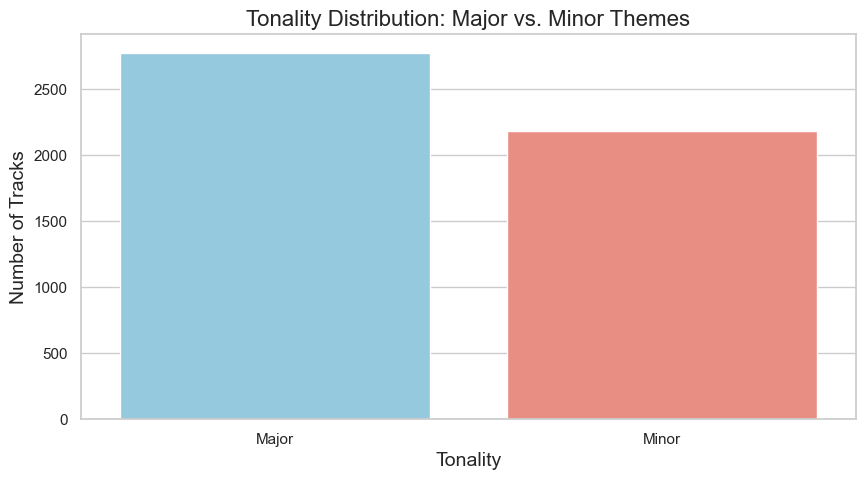

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Plot Major vs Minor dominance
sns.countplot(data=df, x='tonality', palette={'Major': 'skyblue', 'Minor': 'salmon', 'Unknown': 'gray'})

plt.title("Tonality Distribution: Major vs. Minor Themes", fontsize=16)
plt.xlabel("Tonality", fontsize=14)
plt.ylabel("Number of Tracks", fontsize=14)
plt.show()

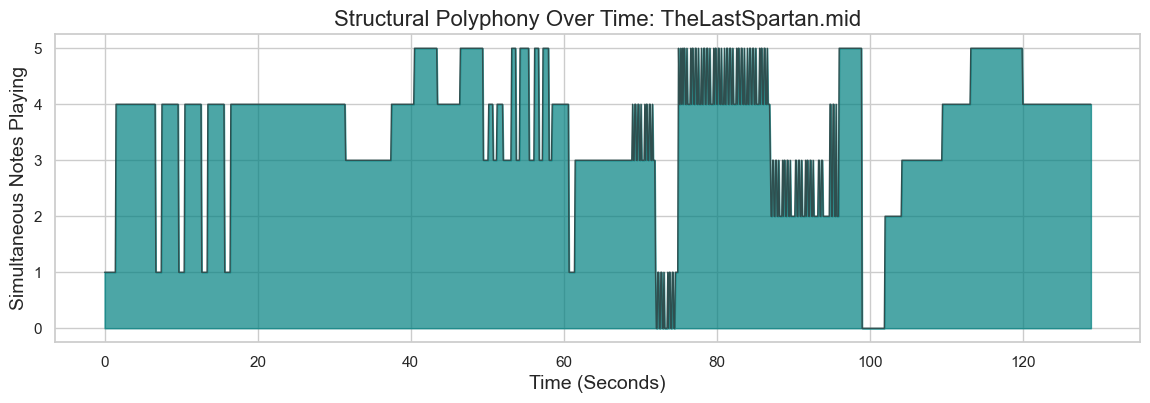

In [8]:
def plot_polyphony_from_df(row_index, dataframe, sample_rate=10):
    """
    Plots structural polyphony over time using pre-extracted DataFrame metrics.
    """
    # Grab the specific song from the dataframe
    song = dataframe.iloc[row_index]
    
    starts = song['all_start_times']
    durations = song['all_durations']
    duration_total = song['duration']
    song_name = song['song_name']
    
    # Create an array of time steps (e.g., 0.0, 0.1, 0.2 ... duration)
    time_steps = np.arange(0, duration_total, 1.0 / sample_rate)
    polyphony = np.zeros(len(time_steps))
    
    # Calculate density instantly using the extracted lists
    for start, dur in zip(starts, durations):
        end = start + dur
        
        # Convert seconds to array indices
        start_idx = int(start * sample_rate)
        end_idx = int(end * sample_rate)
        
        # Safety check to prevent array overflow
        if start_idx < len(polyphony):
            end_idx = min(end_idx, len(polyphony))
            polyphony[start_idx:end_idx] += 1

    # --- Plotting ---
    plt.figure(figsize=(14, 4))
    
    plt.fill_between(time_steps, polyphony, color='teal', alpha=0.7)
    plt.plot(time_steps, polyphony, color='darkslategray', linewidth=1)

    plt.title(f"Structural Polyphony Over Time: {song_name}", fontsize=16)
    plt.xlabel("Time (Seconds)", fontsize=14)
    plt.ylabel("Simultaneous Notes Playing", fontsize=14)
    plt.show()

# Example usage: Plot the very first song in your dataframe
plot_polyphony_from_df(row_index=0, dataframe=df)

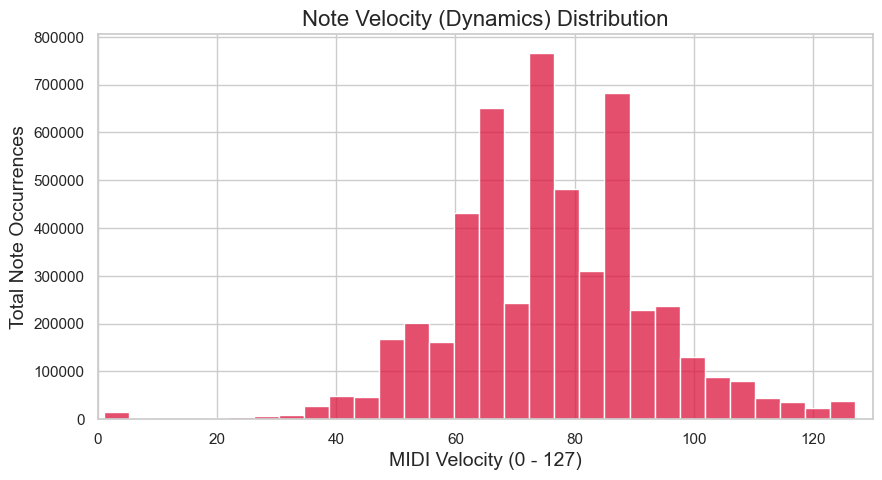

In [9]:
global_velocities = [vel for song in df['all_velocities'] for vel in song]

plt.figure(figsize=(10, 5))
sns.histplot(global_velocities, bins=30, color='crimson')

plt.title("Note Velocity (Dynamics) Distribution", fontsize=16)
plt.xlabel("MIDI Velocity (0 - 127)", fontsize=14)
plt.ylabel("Total Note Occurrences", fontsize=14)
plt.xlim(0, 130)
plt.show()

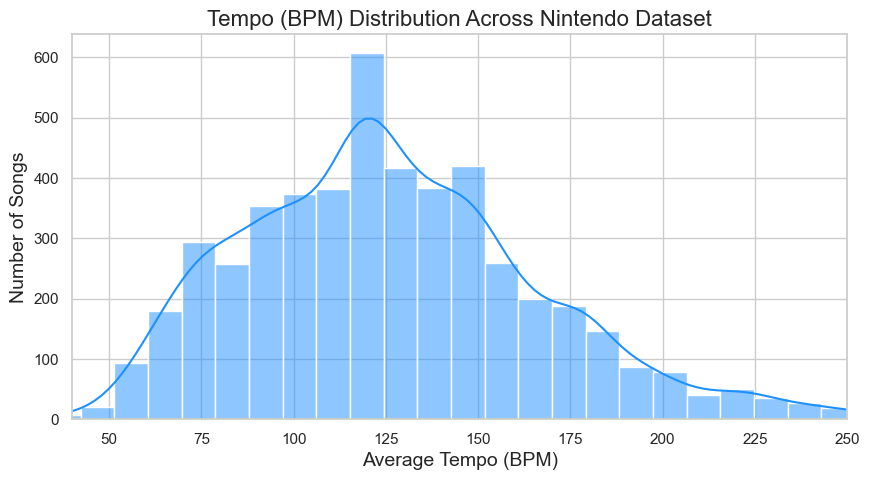

In [10]:
plt.figure(figsize=(10, 5))
# KDE overlay helps show the "bimodal" humps (e.g., slow menus vs fast battles)
sns.histplot(data=df, x='avg_tempo', bins=40, color='dodgerblue', kde=True)

plt.title("Tempo (BPM) Distribution Across Nintendo Dataset", fontsize=16)
plt.xlabel("Average Tempo (BPM)", fontsize=14)
plt.ylabel("Number of Songs", fontsize=14)
plt.xlim(40, 250) # Cut off extreme outliers to keep the plot readable
plt.show()

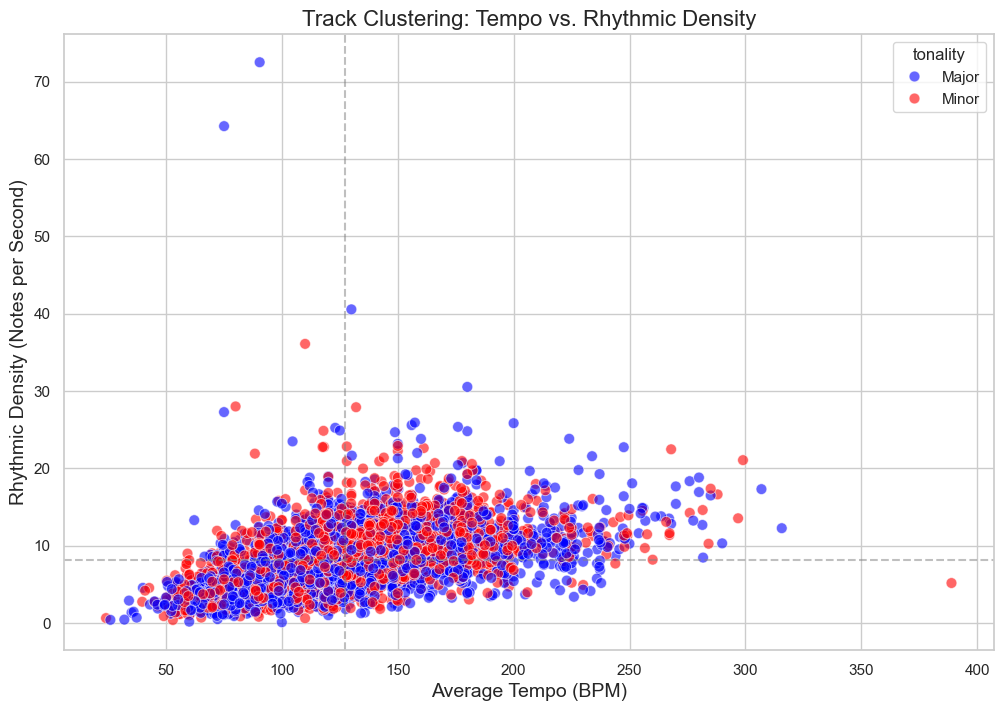

In [11]:
plt.figure(figsize=(12, 8))

# Scatter plot of Tempo vs Density, colored by Major/Minor
sns.scatterplot(
    data=df[df['tonality'] != 'Unknown'], # Filter out unknown keys for a cleaner plot
    x='avg_tempo', 
    y='rhythmic_density', 
    hue='tonality',
    palette={'Major': 'blue', 'Minor': 'red'},
    alpha=0.6,
    s=60 # Dot size
)

plt.title("Track Clustering: Tempo vs. Rhythmic Density", fontsize=16)
plt.xlabel("Average Tempo (BPM)", fontsize=14)
plt.ylabel("Rhythmic Density (Notes per Second)", fontsize=14)

# Add quadrant lines based on dataset averages to show boundaries
plt.axvline(df['avg_tempo'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.axhline(df['rhythmic_density'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.show()

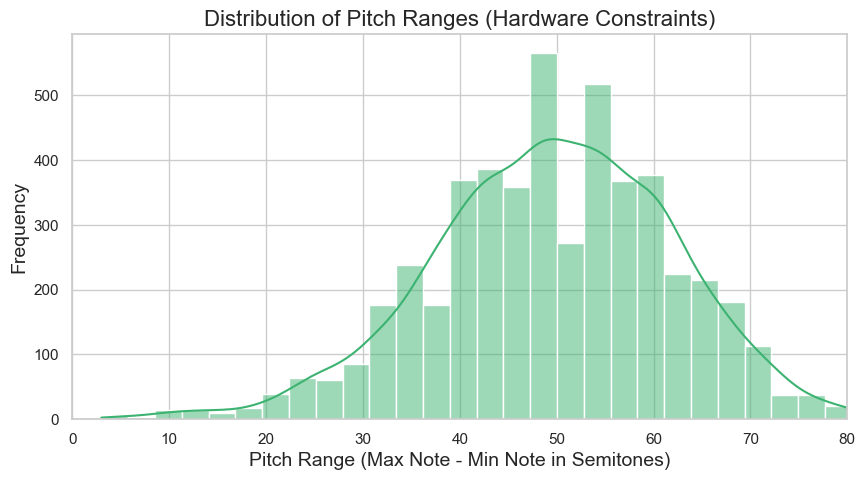

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='pitch_range', bins=30, color='mediumseagreen', kde=True)

plt.title("Distribution of Pitch Ranges (Hardware Constraints)", fontsize=16)
plt.xlabel("Pitch Range (Max Note - Min Note in Semitones)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xlim(0, 80)
plt.show()

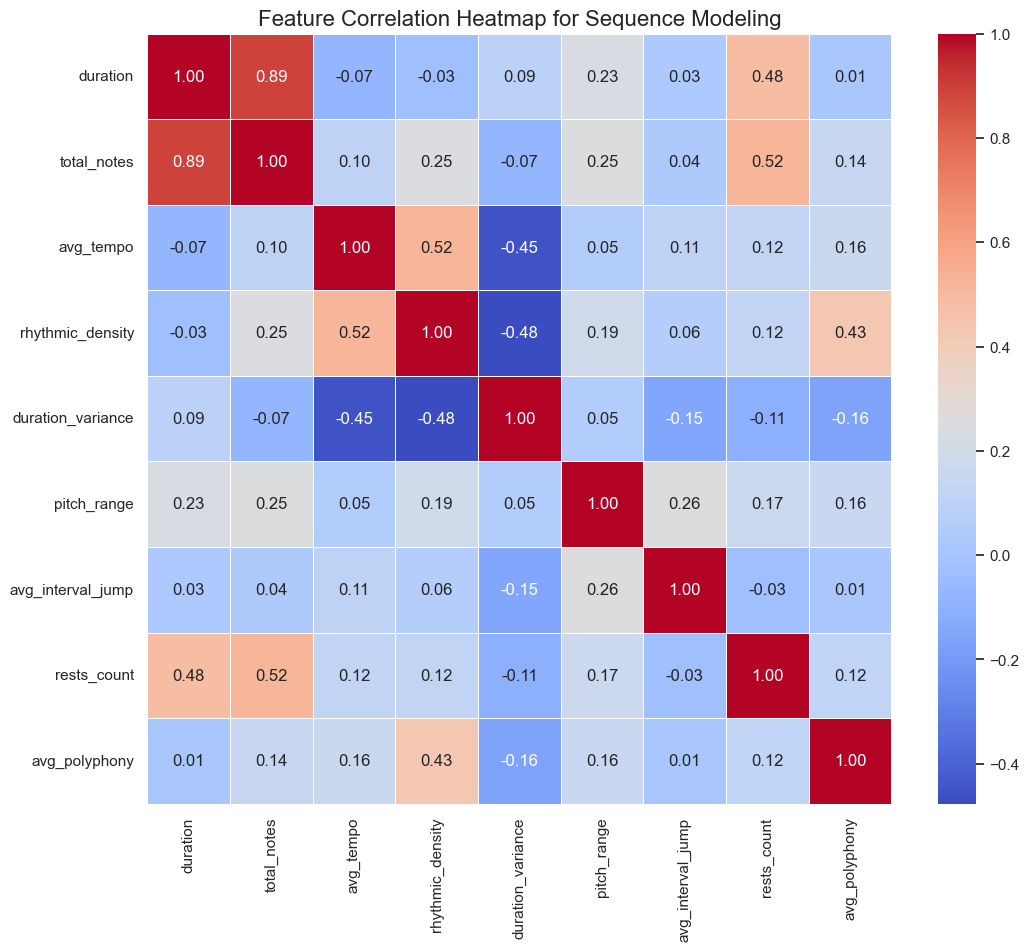

In [13]:
plt.figure(figsize=(12, 10))

# Select only the numerical columns for correlation
numeric_cols = ['duration', 'total_notes', 'avg_tempo', 'rhythmic_density', 
                'duration_variance', 'pitch_range', 'avg_interval_jump', 
                'rests_count', 'avg_polyphony']

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Heatmap for Sequence Modeling", fontsize=16)
plt.show()

C:\Users\altai\AppData\Local\Temp\ipykernel_32664\3436898953.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=note_names, y=ordered_counts, palette='magma')


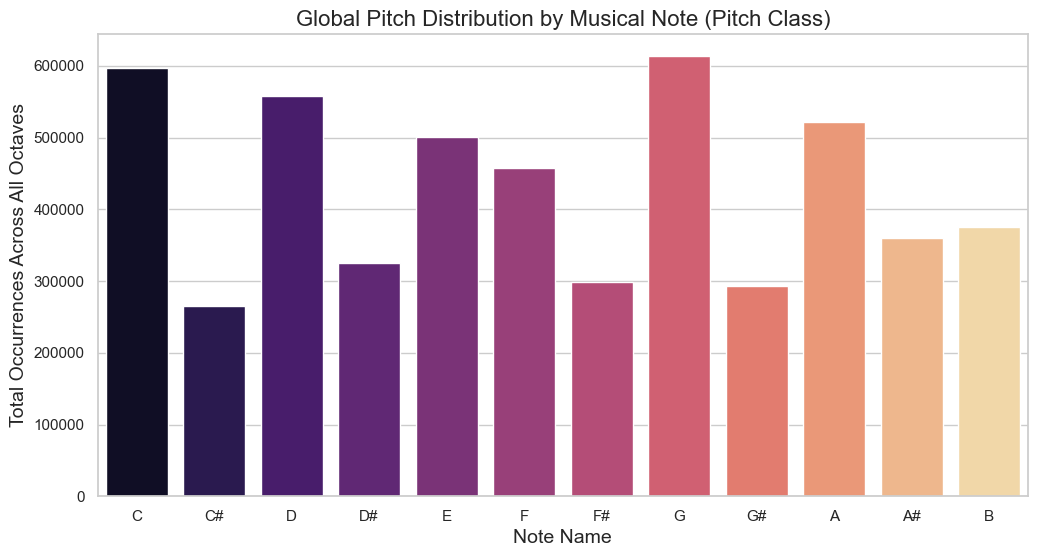

In [14]:
sns.set_theme(style="whitegrid")

# 1. Define the 12 musical notes in order
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

# 2. Convert all raw MIDI numbers in your flattened list to their actual note names
# e.g., 60 % 12 = 0 ('C'),  61 % 12 = 1 ('C#')
global_notes = [note_names[pitch % 12] for pitch in global_pitches]

# 3. Count how many times each note appears
note_counts = Counter(global_notes)

# 4. Extract the counts in strict musical order (C to B) so the plot doesn't shuffle them
ordered_counts = [note_counts.get(note, 0) for note in note_names]

# 5. Plot the Pitch Class Distribution
plt.figure(figsize=(12, 6))

# Using a barplot instead of a histplot since our data is now categorical
sns.barplot(x=note_names, y=ordered_counts, palette='magma')

plt.title("Global Pitch Distribution by Musical Note (Pitch Class)", fontsize=16)
plt.xlabel("Note Name", fontsize=14)
plt.ylabel("Total Occurrences Across All Octaves", fontsize=14)

plt.show()

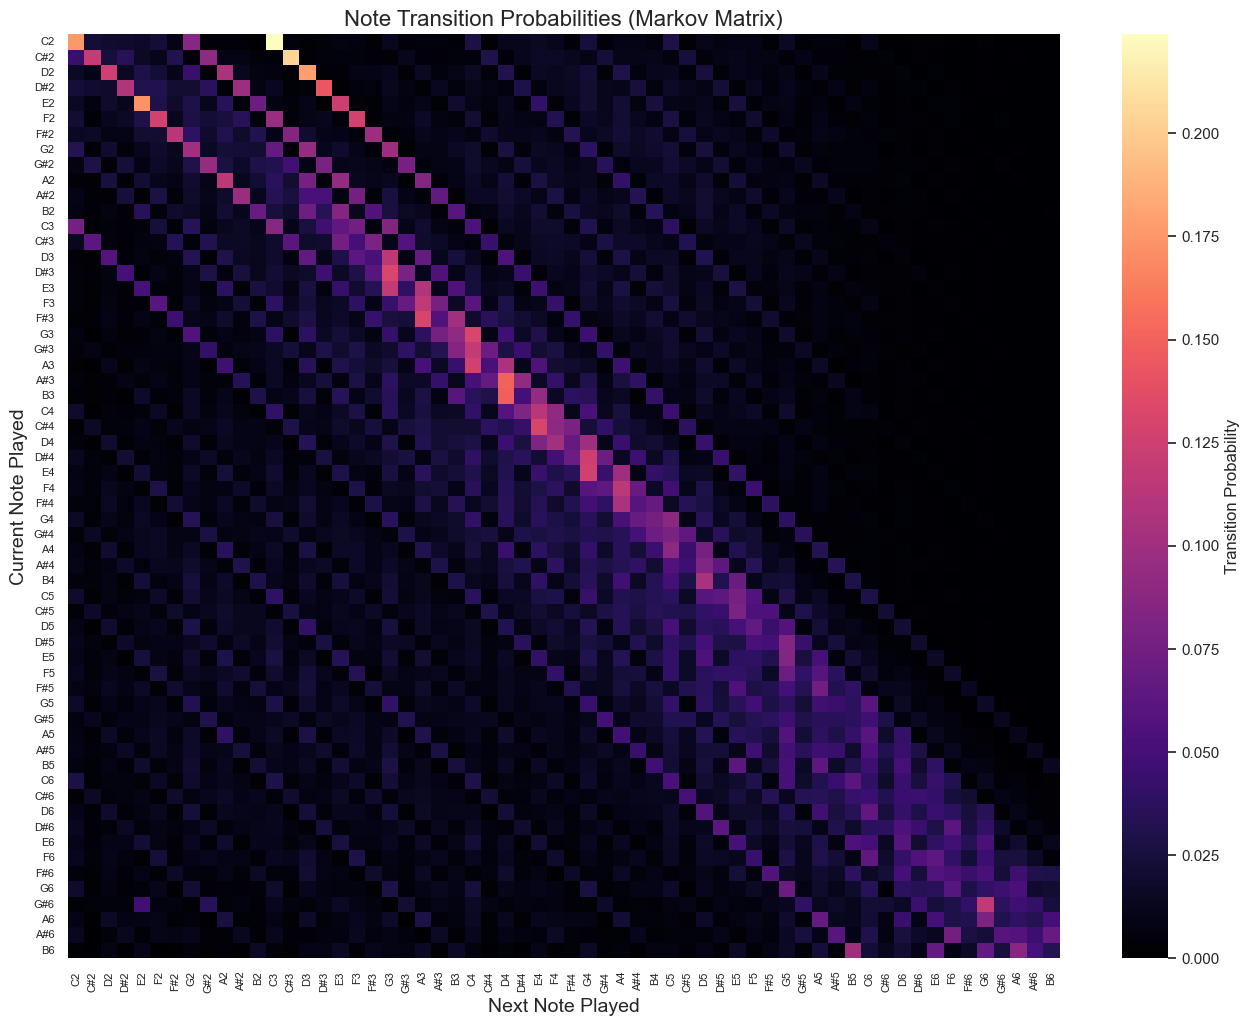

In [15]:
transition_counts = np.zeros((128, 128))

# 2. Loop through each song in your dataframe safely
for pitches in df['all_pitches']:
    # We stop 1 note early because the last note has no "next" note
    for i in range(len(pitches) - 1):
        current_note = pitches[i]
        next_note = pitches[i+1]
        transition_counts[current_note, next_note] += 1

# 3. Convert raw counts into Probabilities (The Markov Rule)
# We divide each row by its sum. If a row sums to 0 (note never played), we keep it 0.
row_sums = transition_counts.sum(axis=1, keepdims=True)
probability_matrix = np.divide(transition_counts, row_sums, 
                               out=np.zeros_like(transition_counts), 
                               where=row_sums!=0)

# 4. Zoom in on the active playable range (C2 to C7)
min_note = 36 
max_note = 96 
active_matrix = probability_matrix[min_note:max_note, min_note:max_note]

# --- NEW: Generate actual musical note labels ---
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

def midi_to_note_string(midi_num):
    octave = (midi_num // 12) - 1
    note = note_names[midi_num % 12]
    return f"{note}{octave}"

# Create a list of labels (e.g., ['C2', 'C#2', 'D2' ... 'B6'])
tick_labels = [midi_to_note_string(i) for i in range(min_note, max_note)]

# 5. Plot the Heatmap
plt.figure(figsize=(16, 12)) # Made slightly larger to fit all the text labels

# Pass the custom labels directly to seaborn
sns.heatmap(active_matrix, cmap='magma', 
            xticklabels=tick_labels, yticklabels=tick_labels,
            cbar_kws={'label': 'Transition Probability'})

plt.title("Note Transition Probabilities (Markov Matrix)", fontsize=16)
plt.xlabel("Next Note Played", fontsize=14)
plt.ylabel("Current Note Played", fontsize=14)

# Rotate X labels so they don't overlap, keep Y labels horizontal
plt.xticks(rotation=90, fontsize=8) 
plt.yticks(rotation=0, fontsize=8)

plt.show()

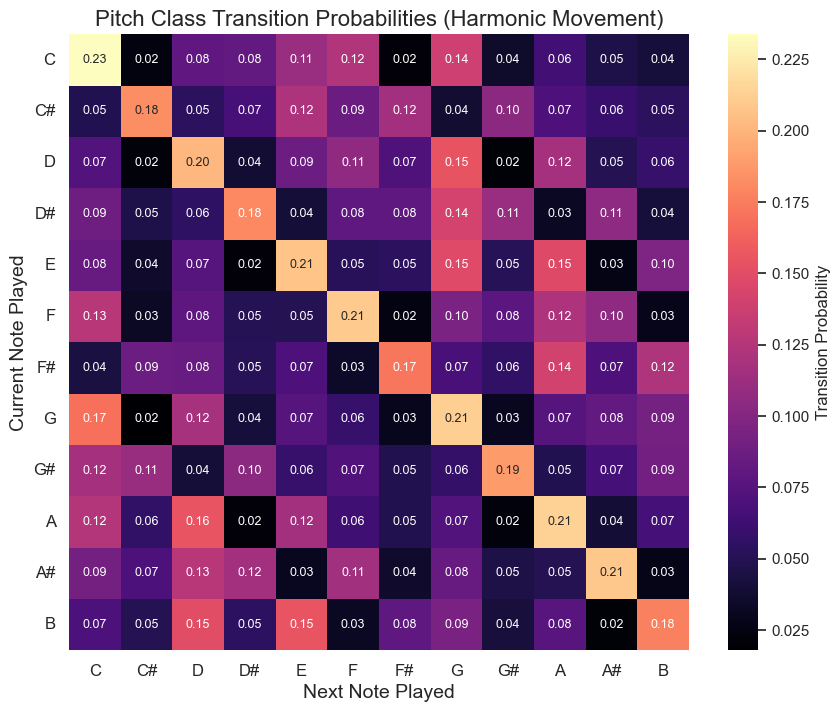

In [16]:
transition_counts = np.zeros((12, 12))

# 2. Loop through each song in your dataframe safely
for pitches in df['all_pitches']:
    # Stop 1 note early because the last note has no "next" note
    for i in range(len(pitches) - 1):
        # Use modulo 12 to ignore the octave and extract the base pitch class
        current_note = pitches[i] % 12
        next_note = pitches[i+1] % 12
        
        transition_counts[current_note, next_note] += 1

# 3. Convert raw counts into Probabilities
# Divide each row by its sum to get values between 0.0 and 1.0
row_sums = transition_counts.sum(axis=1, keepdims=True)
probability_matrix = np.divide(transition_counts, row_sums, 
                               out=np.zeros_like(transition_counts), 
                               where=row_sums!=0)

# 4. Plot the Heatmap
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

plt.figure(figsize=(10, 8))

# Using annot=True to overlay the exact mathematical probabilities on the chart
sns.heatmap(probability_matrix, cmap='magma', 
            xticklabels=note_names, yticklabels=note_names,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            cbar_kws={'label': 'Transition Probability'})

plt.title("Pitch Class Transition Probabilities (Harmonic Movement)", fontsize=16)
plt.xlabel("Next Note Played", fontsize=14)
plt.ylabel("Current Note Played", fontsize=14)

# Keep the note labels upright for easy reading
plt.xticks(rotation=0, fontsize=12) 
plt.yticks(rotation=0, fontsize=12)

plt.show()

In [17]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

print("--- 80/20 SPLIT RESULTS ---")
print(f"Train Set Size: {len(train_df)} songs")
print(f"Test Set Size:  {len(test_df)} songs\n")

--- 80/20 SPLIT RESULTS ---
Train Set Size: 3968 songs
Test Set Size:  992 songs



In [18]:
train_df.head(10)

,game_name,song_name,duration,total_notes,unique_pitches_in_file,min_pitch,max_pitch,unique_durations_in_file,key,tonality,...,rests_count,pitch_class_hist,instrument_programs,avg_polyphony,melody_tracks,harmony_tracks,all_pitches,all_durations,all_start_times,all_velocities
4449,LongLivetheQueen,TalkingBusy.mid,47.76,263,31,35,99,40,F#,Major,...,0,"[0.0076045627376425855, 0.25475285171102663, 0...",[1],1.26,0,1,"[73, 71, 49, 70, 70, 54, 49, 70, 58, 49, 70, 5...","[0.132, 0.126, 0.268, 0.57, 0.008, 0.265, 0.26...","[0.0054259765625000005, 0.14270318359375, 0.56...","[52, 49, 44, 54, 50, 45, 44, 52, 47, 44, 50, 4..."
1204,PaperMarioTheThousandYearDoor,ShadowSirenScuffle.mid,92.74,741,41,30,86,40,G,Minor,...,71,"[0.09851551956815115, 0.021592442645074223, 0....",[0],1.62,0,1,"[48, 48, 43, 57, 55, 43, 54, 46, 42, 56, 42, 4...","[0.204, 0.204, 0.193, 0.422, 0.08, 0.194, 0.4,...","[0.004042041015625, 0.004042041015625, 0.22069...","[85, 93, 88, 99, 89, 88, 88, 91, 88, 88, 88, 9..."
80,BravelyDefault,InstantofEternity.mid,109.75,518,22,67,96,46,C,Minor,...,0,"[0.20077220077220076, 0.0, 0.0888030888030888,...",[1],1.58,0,1,"[84, 72, 91, 75, 79, 96, 84, 94, 77, 93, 94, 9...","[0.423, 0.423, 0.4, 0.4, 0.397, 0.824, 0.426, ...","[0.008375312499999999, 0.008375312499999999, 0...","[67, 67, 62, 62, 63, 63, 62, 65, 65, 62, 62, 5..."
803,Pok�monRubyVersionPok�monSapphireVersion,Route111.mid,82.13,564,40,41,91,46,E,Minor,...,36,"[0.01773049645390071, 0.05673758865248227, 0.0...",[0],1.31,0,1,"[53, 50, 65, 57, 47, 69, 59, 45, 71, 62, 43, 7...","[0.132, 0.132, 0.14, 0.114, 0.114, 0.121, 0.11...","[0.004882841796875, 0.004882841796875, 0.00488...","[61, 69, 75, 56, 64, 70, 56, 64, 70, 56, 64, 7..."
1769,PaperMario,ShyGuysToyBox.mid,79.97,912,53,29,95,49,F,Major,...,129,"[0.08552631578947369, 0.010964912280701754, 0....",[0],2.28,0,1,"[82, 58, 65, 62, 89, 88, 53, 65, 62, 89, 91, 5...","[0.265, 0.265, 0.089, 0.127, 0.252, 0.251, 0.2...","[0.004440498046875001, 0.004440498046875001, 0...","[75, 75, 76, 62, 75, 75, 75, 76, 62, 75, 75, 7..."
2107,PhoenixWrightAceAttorney,DickGumshoeItsDetectiveGumshoePal.mid,111.65,806,25,41,84,59,C,Minor,...,6,"[0.2903225806451613, 0.0, 0.08312655086848635,...",[1],1.84,0,1,"[70, 74, 60, 48, 48, 67, 55, 72, 72, 55, 60, 6...","[0.254, 0.27, 0.272, 0.288, 0.124, 0.254, 0.27...","[1.9120958281249998, 1.9120958281249998, 2.184...","[67, 81, 80, 80, 75, 75, 75, 67, 76, 75, 75, 7..."
3425,KirbyStarAllies,WorldofMiraclesPlanetPopstar.mid,61.08,290,45,41,105,28,A,Major,...,8,"[0.06206896551724138, 0.06896551724137931, 0.1...",[1],1.84,0,1,"[71, 78, 78, 83, 83, 90, 55, 59, 62, 66, 86, 8...","[0.485, 0.485, 0.22, 0.474, 0.22, 0.47, 1.9, 1...","[0.0046511718749999995, 0.0046511718749999995,...","[59, 73, 63, 62, 62, 63, 54, 54, 54, 68, 62, 6..."
2503,Castlevania,WickedChild.mid,120.22,1099,30,43,81,40,D,Minor,...,7,"[0.13557779799818018, 0.01637852593266606, 0.2...",[1],1.68,0,1,"[57, 45, 60, 48, 62, 57, 65, 57, 65, 57, 65, 5...","[0.163, 0.163, 0.163, 0.163, 0.352, 0.175, 0.1...","[0.8890069892578125, 0.8890069892578125, 1.063...","[88, 88, 89, 89, 88, 80, 90, 81, 91, 80, 94, 8..."
3623,NewSuperMarioBrosWii,GhostHouse.mid,105.64,342,44,27,96,37,A,Minor,...,48,"[0.18128654970760233, 0.0, 0.01169590643274853...","[1, 1]",1.32,0,2,"[88, 84, 88, 84, 87, 83, 76, 87, 83, 88, 84, 8...","[0.296, 0.28, 0.278, 0.281, 0.281, 0.278, 0.6,...","[0.005861689453125, 0.320048244140625, 0.61782...","[40, 47, 45, 37, 38, 40, 36, 42, 44, 45, 47, 4..."
4466,Minecraft,Sweden.mid,213.66,508,31,31,86,66,A,Major,...,26,"[0.0, 0.08858267716535433, 0.1377952755905512,...","[0, 0]",2.42,0,2,"[40, 42, 43, 47, 45, 43, 38, 40, 42, 43, 47, 4...","[1.391, 1.352, 1.352, 1.348, 1.399, 1.352, 2.7...","[0.013333330078124999, 1.405332990234375, 2.75...","[27, 24, 24, 26, 27, 29, 30, 33, 36, 38, 39, 4..."


# 2. Modeling

## Context
> Our inputs are the video game music dataset, specifically as midi files translated into tokens. We created these tokens by making a song "word/token" dictionary. Our outputs are probability distributions over the dictionary we created. This building of sequences is the generation portion that actually creates the music as the model takes in data. At a sequence of tokens, the model will predict probabilities for the next token, sample, and then choose/append a token to the sequence, repeating until the whole song is generated. For training and test, and for optimization, we split the data in preprocessing above into an 80-20 split. During training, we optimize by minimizing differences between the predict token and the test set's song tokens. As we created our models, we evaluated the generated song's quality among our teams ears, and decided to update our models as we progressed through the project. In an attempt to make our songs better, we optimized by doing post processing that added behaviors to aid during generating the midi files, which will be further explained below. As for models appropriate for the task we decided on an autoregressive language model, as we have been describing, for both the unconditioned and conditioned symbolic tasks. Both are probabilistic, but our conditioned models are trained with specific behaviors in mind for generation. Our unconditioned model is free to generate its tokens simply based on the probability distribution of the music, while the conditioned model generates based on probabilities that are dependent on given constraints. Specifically our conditioned model's distributions are influenced by given bass lines, and given melodies, singled out by functional token interleaving. 

## Discussion
> We know that autoregressive language models can perform well in music settings, as music can be similar to language, and can be tokenized similarly. Our training involves processing sequence windows with causal masks, and computing possible links between notes in 128 token windows. These windows act as context windows in a way, and help the model remember past musical motifs during generation. This 128 token window size is a computational constraint, and we think that having a smaller window like this is what makes the model musically drift during generation, as it can only "remember" motifs in this short window. This explains why even with a given seed of starting music, as the model continues generation it references its own history, which may make the music sound worse as time goes on.
> In class, we learned about Markov Chains and their use in musical settings. This algorithm/system keeps a dictionary count of token transitions, but only chooses a note dependent on the last note (bigrams). This would have the same kind of "memory" problem as our model, not being able to generalize to the music or keep a structure. We felt as if this model would be too simple, and as its "memory" is even worse than our model, would probably generate music that got crazy and not very good sounding very fast.

## Code
### Task 1
> Our first step is serializing the song into tokens so that we can learn the "wording" of songs and thus generate songs through tokens by assigning unique tokens to an id, basically creating a song "word" dictionary to tokenize training and test data and show an example of a song in the training set's tokens and ID. From there, we iterate through the training and test data and slice them into windows to process and get multiple samples out of each song, where using a stride of 64 creates less windows of data, meaning less overlap of samples in each song, and thus less overlap of learning in songs. We wanted to hopefully capture the generality of music better. We build a causal transformer decoder to hide future steps to force learning in progress, while also adding position values to the token vectors for the network to know where a note is on the timeline, and we use an optimization module to track training and validation loss across epochs to show learning and plot the progress of training and validation loss. Now that the model is trained, we create an inference loop to generate music using autoregressive generation where we give a short seed or first notes and make the model look at the context. It calculates the probability distribution over the vocabulary to guess the next token, then sample the token and add it to the track as the generative part. Finally, we slide the window forward to include the token and repeat until a full track is created, and we created a few different seeds to try to guide model generation toward certain sentiments/"feelings"/settings of music, like overworld, boss fight, and dungeon, while adjusting velocity during generation to try to keep the volume consistent.

### Task 2
> For our conditioned model, we will force the model to generate a melody/leading track using a bassline so that the model generates based on a pre-given input of a melody/bassline that already sounds decent, hopefully guiding the model to create a decent sounding song that holds an identity throughout generation. We will weave bass and melody notes together chronologically, as a functional token interleaving approach where the added tokens will be added to the dictionary of tokens we have already and used for learning, and the new model is trained using this updated dictionary. 
> Generation works by reading the next token from our conditioning bass line timeline (e.g., BassOn_36 or TimeShift_0.25), appending that bass/time token to our model's context window, and forcing the model to look at that context and predict only the next melodic lead token (MelOn_ or MelOff_). We repeat this process, allowing the model to freely compose the melody while strictly sticking to the rhythmic grid and harmonic backbone provided by the bass line. To condition on a premade bass line, we will take one of the songs from the test set and use it as a skeleton by taking away its melody tokens to create the bass line, then using it as input in our model to create a melody. To see/test how well the melody goes with the bass line, we separated the instruments within the midi file using the labels we created earlier, and can listen to them, distinct in register, and see if they are matching well and if the song sounds good. The original result seemed to not generate a very good sounding song as it seemed to jump keys/pitches pretty randomly while generating, so we attempted to better this by clamping keys to either Major or Minor, which resulted in a better sounding song to our ears. We also tried a model that conditioned on melody, and then created the bass line, so the other way around using essentially the same logic. We felt this is most similar to human created music, where melodies are created first, and backing, as bass or general harmony/chords, is created to make the song sound fuller around the melody. To continue to improve our songs, we added duration clamping as further post processing so that the songs would not be as "muddy" or feel too dense/chaotic, and we were happy with the song that was generated, with the aquatic ruin theme from Sonic The Hedgehog 2 being used as a good starting melody sample.

In [19]:
def serialize_song_to_tokens(pitches, durations, start_times, time_grid=0.25):
    """
    Combine music properties from df into one stream of tokens representing the song
    Example Output: ["NoteOn_60", "TimeShift_0.25", "NoteOff_60", "NoteOn_64", ...]
    """
    events = []
    
    # 1. Zip the elements together so we can track individual notes
    for p, d, s in zip(pitches, durations, start_times):
        # Quantize the start time and end time to our discrete grid
        q_start = round(s / time_grid) * time_grid
        q_end = round((s + d) / time_grid) * time_grid
        
        # Append Note-On and Note-Off event strings
        events.append((q_start, f"NoteOn_{p}"))
        events.append((q_end, f"NoteOff_{p}"))
    
    # 2. Sort all events chronologically by when they occur in time
    events.sort(key=lambda x: x[0])
    
    # 3. Interweave Time-Shift tokens between events
    token_stream = []
    current_time = 0.0
    
    for event_time, event_name in events:
        time_delta = event_time - current_time
        
        # If time has moved forward, insert a TimeShift token
        if time_delta > 0:
            # Rounding prevents floating point errors (e.g., 0.2500000001)
            steps = round(time_delta / time_grid)
            for _ in range(steps):
                token_stream.append(f"TimeShift_{time_grid}")
            current_time = event_time
            
        token_stream.append(event_name)
        
    return token_stream

In [20]:
class VideoGameMusicTokenizer:
    def __init__(self):
        # Initialize our system with mandatory structural tokens
        self.special_tokens = ["<PAD>", "<UNK>"]
        self.token_to_id = {tok: i for i, tok in enumerate(self.special_tokens)}
        self.id_to_token = {i: tok for tok, i in self.token_to_id.items()}
        self.vocab_size = len(self.special_tokens)

    def fit(self, tokenized_series):
        """Scans your training streams to lock down your vocabulary size"""
        unique_tokens = set()
        for stream in tokenized_series:
            unique_tokens.update(stream)
            
        # Add found tokens to dictionary
        for tok in sorted(list(unique_tokens)):
            if tok not in self.token_to_id:
                idx = self.vocab_size
                self.token_to_id[tok] = idx
                self.id_to_token[idx] = tok
                self.vocab_size += 1
                
        print(f"--- VOCABULARY ENGINE INITIALIZED ---")
        print(f"Total Unique Token Choices (Vocab Size): {self.vocab_size}")

    def encode(self, token_list):
        return [self.token_to_id.get(tok, self.token_to_id["<UNK>"]) for tok in token_list]

    def decode(self, id_list):
        return [self.id_to_token.get(idx, "<UNK>") for idx in id_list]

In [21]:
print("Serializing training tracks into structural token streams...")

# 1. Apply chronological serialization to both partitions
train_df['token_stream'] = train_df.apply(
    lambda row: serialize_song_to_tokens(row['all_pitches'], row['all_durations'], row['all_start_times']), axis=1
)
test_df['token_stream'] = test_df.apply(
    lambda row: serialize_song_to_tokens(row['all_pitches'], row['all_durations'], row['all_start_times']), axis=1
)

# 2. Fit the dictionary using ONLY the training songs to prevent data leakage
vgm_tokenizer = VideoGameMusicTokenizer()
vgm_tokenizer.fit(train_df['token_stream'])

# 3. Translate the strings into integer token arrays for PyTorch
train_df['encoded_ids'] = train_df['token_stream'].apply(lambda x: vgm_tokenizer.encode(x))
test_df['encoded_ids'] = test_df['token_stream'].apply(lambda x: vgm_tokenizer.encode(x))

Serializing training tracks into structural token streams...
--- VOCABULARY ENGINE INITIALIZED ---
Total Unique Token Choices (Vocab Size): 209


In [23]:
print("Verification Check:")
print(f"Game Name: {train_df['game_name'].iloc[0]}")
print(f"Song Name: {train_df['song_name'].iloc[0]}")
print(f"First 6 Raw String Tokens: {train_df['token_stream'].iloc[0][:6]}")
print(f"First 6 Encoded Token IDs:  {train_df['encoded_ids'].iloc[0][:6]}")

Verification Check:
Game Name: LongLivetheQueen
Song Name: TalkingBusy.mid
First 6 Raw String Tokens: ['NoteOn_73', 'TimeShift_0.25', 'NoteOff_73', 'NoteOn_71', 'NoteOff_71', 'NoteOn_70']
First 6 Encoded Token IDs:  [180, 208, 77, 178, 75, 177]


In [ ]:
# import torch
# from torch.utils.data import Dataset, DataLoader

# class VGMSequenceDataset(Dataset):
#     def __init__(self, encoded_id_series, max_seq_len=128, stride=16):
#         self.X_samples = []
#         self.Y_samples = []
        
#         # Loop through the token arrays of each song in the partition
#         for token_ids in encoded_id_series:
#             # If a song is too short to fill a context window, skip or pad it
#             if len(token_ids) <= max_seq_len:
#                 continue
                
#             # Slide a window across the individual song stream
#             for i in range(0, len(token_ids) - max_seq_len, stride):
#                 window = token_ids[i : i + max_seq_len + 1]
                
#                 # X is tokens [0, 1, ..., max_seq_len-1]
#                 x_slice = window[:-1]
#                 # Y is tokens [1, 2, ..., max_seq_len] (shifted by 1)
#                 y_slice = window[1:]
                
#                 self.X_samples.append(x_slice)
#                 self.Y_samples.append(y_slice)
                
#         # Convert our massive list of windows into highly optimized PyTorch LongTensors
#         self.X_samples = torch.tensor(self.X_samples, dtype=torch.long)
#         self.Y_samples = torch.tensor(self.Y_samples, dtype=torch.long)
        
#     def __len__(self):
#         return len(self.X_samples)
        
#     def __getitem__(self, idx):
#         return self.X_samples[idx], self.Y_samples[idx]

# # ---------------------------------------------------------
# # Instantiate the Data Loaders for PyTorch
# # ---------------------------------------------------------
# MAX_SEQ_LEN = 128
# BATCH_SIZE = 64

# print("Slicing token streams into tensor window matrices...")
# train_dataset = VGMSequenceDataset(train_df['encoded_ids'], max_seq_len=MAX_SEQ_LEN, stride=16)
# test_dataset = VGMSequenceDataset(test_df['encoded_ids'], max_seq_len=MAX_SEQ_LEN, stride=16)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# print(f"Total Training Window Batches Generated: {len(train_loader)}")
# print(f"Total Testing Window Batches Generated:  {len(test_loader)}")

Slicing token streams into tensor window matrices...
Total Training Window Batches Generated: 9522
Total Testing Window Batches Generated:  2530


In [50]:
import torch
from torch.utils.data import Dataset, DataLoader

class VGMSequenceDataset(Dataset):
    def __init__(self, encoded_id_series, max_seq_len=128, stride=16):
        print("Pre-allocating master memory blocks...")
        raw_X = []
        raw_Y = []
        
        # 1. Quickly collect all windows into memory once
        for token_ids in encoded_id_series:
            if len(token_ids) <= max_seq_len:
                continue
            for i in range(0, len(token_ids) - max_seq_len, stride):
                window = token_ids[i : i + max_seq_len + 1]
                raw_X.append(window[:-1])
                raw_Y.append(window[1:])
        
        # 2. Convert to PyTorch tensors IMMEDIATELY here
        # This keeps all samples grouped in a contiguous block of hardware memory
        self.X_samples = torch.tensor(raw_X, dtype=torch.long)
        self.Y_samples = torch.tensor(raw_Y, dtype=torch.long)
        
        print(f"Total compiled sequences: {len(self.X_samples)}")

    def __len__(self):
        return len(self.X_samples)

    def __getitem__(self, idx):
        # Zero CPU slicing overhead during actual training batches!
        return self.X_samples[idx], self.Y_samples[idx]
    
# ---------------------------------------------------------
# Instantiate the Data Loaders for PyTorch
# ---------------------------------------------------------
MAX_SEQ_LEN = 128
BATCH_SIZE = 256

print("Slicing token streams into tensor window matrices...")
train_dataset = VGMSequenceDataset(train_df['encoded_ids'], max_seq_len=MAX_SEQ_LEN, stride=64)
test_dataset = VGMSequenceDataset(test_df['encoded_ids'], max_seq_len=MAX_SEQ_LEN, stride=64)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"Total Training Window Batches Generated: {len(train_loader)}")
print(f"Total Testing Window Batches Generated:  {len(test_loader)}")

Slicing token streams into tensor window matrices...
Pre-allocating master memory blocks...
Total compiled sequences: 153821
Pre-allocating master memory blocks...
Total compiled sequences: 40825
Total Training Window Batches Generated: 601
Total Testing Window Batches Generated:  160


In [51]:
import torch.nn as nn
import math

class VideoGameTransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, num_heads=4, num_layers=3, max_seq_len=128):
        super().__init__()
        self.max_seq_len = max_seq_len
        
        # Layer 1: Trainable Continuous Token Embeddings (Maps discrete IDs to dense spaces)
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        # Layer 2: Positional Embeddings (Injects sequential tracking awareness)
        self.position_embedding = nn.Embedding(max_seq_len, embed_dim)
        
        # Layer 3: Core Multi-Head Attention Blocks stacked vertically
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_stack = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        
        # Layer 4: Linear Head projecting dense layers back into vocab index predictions
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        
    def _generate_causal_mask(self, sz, device):
        """Creates an upper-triangular mask blocking attention from looking forward in time"""
        mask = torch.triu(torch.ones(sz, sz, device=device)) == 1
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def forward(self, x):
        batch_size, seq_len = x.size()
        device = x.device
        
        # Generate our positional sequence markers: [0, 1, 2, ..., seq_len-1]
        pos_indices = torch.arange(0, seq_len, device=device).unsqueeze(0).expand(batch_size, seq_len)
        
        # Sum both embeddings together (Standard Transformer standard)
        embedded_vectors = self.token_embedding(x) + self.position_embedding(pos_indices)
        
        # Construct the strict casual mask block
        causal_mask = self._generate_causal_mask(seq_len, device)
        
        # Pass tokens through attention. 
        # For an autoregressive decoder, hidden representations act as target and memory blocks
        hidden_states = self.transformer_stack(
            tgt=embedded_vectors, 
            memory=embedded_vectors, 
            tgt_mask=causal_mask, 
            memory_mask=causal_mask
        )
        
        # Project our final continuous activations to vocabulary prediction logits
        logits = self.fc_out(hidden_states)
        return logits

In [52]:
# Check if a CUDA-enabled GPU or Apple Silicon GPU is present to accelerate modeling run
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the network using your specific tokenizer vocab size
model = VideoGameTransformerDecoder(vocab_size=vgm_tokenizer.vocab_size, max_seq_len=MAX_SEQ_LEN)
model = model.to(device)

print(f"Model successfully deployed to target device hardware: {device}")
print(model)

Model successfully deployed to target device hardware: cuda
VideoGameTransformerDecoder(
  (token_embedding): Embedding(209, 256)
  (position_embedding): Embedding(128, 256)
  (transformer_stack): TransformerDecoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)


In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm

# ---------------------------------------------------------
# Define the loss function, ignoring padding tokens in loss calculation
criterion = nn.CrossEntropyLoss(ignore_index=vgm_tokenizer.token_to_id["<PAD>"])

# AdamW is the industry standard optimizer for Transformer sequence models
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Learning rate scheduler helps stabilize training as convergence approaches
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

scaler = torch.amp.GradScaler()  # For mixed precision training (if supported)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training Batches", leave=False)
    
    for batch_idx, (batch_X, batch_Y) in enumerate(progress_bar):
        batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
        
        # 1. Clear gradients from the previous batch
        optimizer.zero_grad(set_to_none=True)  # More efficient than optimizer.zero_grad() in newer PyTorch versions
        
        # 2. Forward pass: compute vocabulary prediction logits
        # Shape: [Batch_Size, Seq_Len, Vocab_Size]
        logits = model(batch_X)
        
        # 3. Reshape tensors to fit PyTorch's CrossEntropyLoss requirements
        # Logits must be flattened to [Batch_Size * Seq_Len, Vocab_Size]
        # Targets must be flattened to [Batch_Size * Seq_Len]
        loss = criterion(logits.view(-1, logits.size(-1)), batch_Y.view(-1))
        
        # 4. Backward pass: compute structural gradients
        loss.backward()
        
        # Gradient clipping prevents the vanishing/exploding gradient problems common in sequences
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 5. Update model weights
        optimizer.step()
        
        total_loss += loss.item()

        if batch_idx % 50 == 0: 
            progress_bar.set_postfix({"Batch Loss": f"{loss.item():.4f}"})
        
    return total_loss / len(dataloader)


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    # Disable gradient tracking to conserve memory and speed up computation
    with torch.no_grad():
        for batch_X, batch_Y in dataloader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            logits = model(batch_X)
            loss = criterion(logits.view(-1, logits.size(-1)), batch_Y.view(-1))
            total_loss += loss.item()
            
    return total_loss / len(dataloader)

In [54]:
# Storage matrices for final evaluation plotting
train_loss_history = []
val_loss_history = []

EPOCHS = 10
print(f"Beginning optimization execution loop on {device}...")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # Run structural loops
    epoch_train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    epoch_val_loss = validate_one_epoch(model, test_loader, criterion, device)
    
    # Update scheduler steps based on validation convergence
    scheduler.step(epoch_val_loss)
    
    # Store histories for Section 3 (Evaluation) graphics
    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Time: {elapsed_time:.1f}s")

print("\n--- OPTIMIZATION MATRIX COMPLETION ---")

Beginning optimization execution loop on cuda...


Epoch 01/10 | Train Loss: 0.2582 | Val Loss: 0.0294 | Time: 191.2s


Epoch 02/10 | Train Loss: 0.0290 | Val Loss: 0.0284 | Time: 196.1s


Epoch 03/10 | Train Loss: 0.0283 | Val Loss: 0.0280 | Time: 190.2s


Epoch 04/10 | Train Loss: 0.0280 | Val Loss: 0.0280 | Time: 180.3s


...

Epoch 06/10 | Train Loss: 0.0277 | Val Loss: 0.0278 | Time: 195.7s


Epoch 07/10 | Train Loss: 0.0278 | Val Loss: 0.0279 | Time: 194.9s


Epoch 08/10 | Train Loss: 0.0279 | Val Loss: 0.0278 | Time: 193.1s


Epoch 09/10 | Train Loss: 0.0278 | Val Loss: 0.0278 | Time: 177.9s


Epoch 10/10 | Train Loss: 0.0278 | Val Loss: 0.0278 | Time: 179.8s

--- OPTIMIZATION MATRIX COMPLETION ---


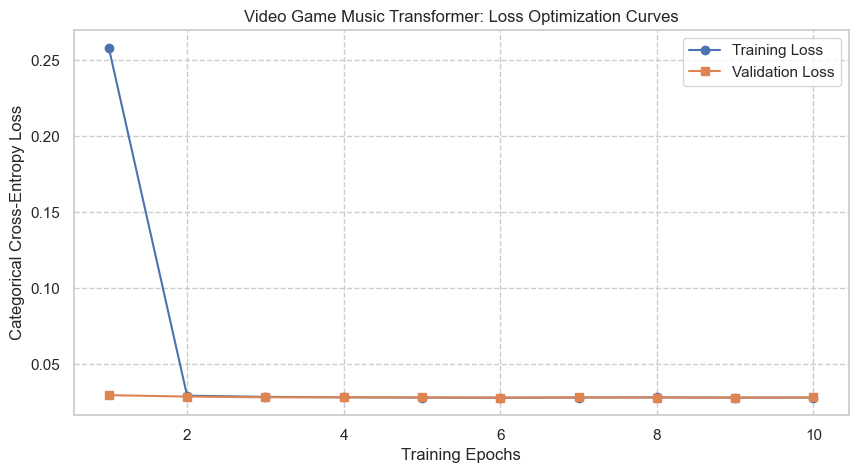

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_loss_history, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), val_loss_history, label='Validation Loss', marker='s')
plt.title('Video Game Music Transformer: Loss Optimization Curves')
plt.xlabel('Training Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

In [ ]:
import torch.nn.functional as F

def generate_music_sequence(model, tokenizer, seed_tokens, max_gen_len=3000, temperature=1.0):
    """
    Autoregressively generates a stream of music token strings from an optimized model.
    temperature: Controls creativity. Lower (<1.0) makes choices more predictable; 
                 higher (>1.0) introduces chaotic, jazz-like behavior.
    """
    model.eval()
    generated_ids = tokenizer.encode(seed_tokens)
    
    with torch.no_grad():
        for _ in range(max_gen_len):
            # 1. Truncate context if it exceeds our model's absolute maximum context capacity
            context_ids = generated_ids[-MAX_SEQ_LEN:]
            
            # 2. Convert to PyTorch tensor and add a batch dimension
            input_tensor = torch.tensor([context_ids], dtype=torch.long).to(device)
            
            # 3. Pass through model to pull out next-step logits
            # Shape: [1, Current_Seq_Len, Vocab_Size]
            logits = model(input_tensor)
            
            # 4. Extract only the logit prediction vector of the final time step
            next_token_logits = logits[0, -1, :] / temperature
            
            # 5. Apply Softmax to convert raw activations to a probability map
            probs = F.softmax(next_token_logits, dim=-1)
            
            # 6. Sample a token ID randomly based on the weight distribution
            next_token_id = torch.multinomial(probs, num_samples=1).item()
            
            # Stop generating early if the model hits an absolute padding block
            if next_token_id == tokenizer.token_to_id["<PAD>"]:
                break
                
            generated_ids.append(next_token_id)
            
    # Decode the final compiled array of numerical IDs back into human-readable strings
    return tokenizer.decode(generated_ids)

In [93]:
# Create an initial seed token phrase to establish your vintage arcade key signature
seed = ["NoteOn_60", "NoteOn_64", "TimeShift_0.25", "NoteOff_60", "NoteOff_64"]
# A rapid, ascending C-Major triad (C4 -> E4 -> G4)
overworld_seed = [
    "NoteOn_60", "TimeShift_0.25", "NoteOff_60", # C4
    "NoteOn_64", "TimeShift_0.25", "NoteOff_64", # E4
    "NoteOn_67", "TimeShift_0.25", "NoteOff_67"  # G4
]
# A low, creeping bass movement (A2 -> B-flat2) held for a longer duration
dungeon_seed = [
    "NoteOn_45", "TimeShift_0.50", "NoteOff_45", # Low A2
    "NoteOn_46", "TimeShift_0.50", "NoteOff_46"  # Low B-flat2 (Creates tension)
]
# An A-Minor chord struck aggressively for a brief window
boss_seed = [
    "NoteOn_57", "NoteOn_60", "NoteOn_64",        # A-Minor Triad playing at once
    "TimeShift_0.25", 
    "NoteOff_57", "NoteOff_60", "NoteOff_64"
]

print("Generating Task 1 Unconditioned Chiptune Sequence...")
generated_track_strings = generate_music_sequence(model, vgm_tokenizer, seed_tokens=overworld_seed, max_gen_len=1000, temperature=.67)

print("\n--- SAMPLE GENERATED STREAM PREVIEW ---")
print(generated_track_strings[:15])

Generating Task 1 Unconditioned Chiptune Sequence...

--- SAMPLE GENERATED STREAM PREVIEW ---
['NoteOn_60', 'TimeShift_0.25', 'NoteOff_60', 'NoteOn_64', 'TimeShift_0.25', 'NoteOff_64', 'NoteOn_67', 'TimeShift_0.25', 'NoteOff_67', 'NoteOff_67', 'NoteOff_67', 'NoteOff_67', 'NoteOff_67', 'NoteOff_67', 'NoteOff_67']


In [94]:
import pretty_midi

def export_tokens_to_midi_v2(token_stream, output_filename="task1_controlled.mid", default_program=80):
    """
    Translates musical tokens back to a MIDI file, programmatically adjusting 
    individual note velocities when a dense multi-note chord is active.
    """
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=default_program, name="Chiptune Lead")
    pm.instruments.append(instrument)
    
    current_time = 0.0
    active_notes = {}  # Tracks { pitch: start_time } for open notes
    
    # List to temporarily hold notes so we can adjust their volumes before saving
    pending_notes = [] 

    for token in token_stream:
        if token.startswith("TimeShift_"):
            step_val = float(token.split("_")[1])
            current_time += step_val
            
        elif token.startswith("NoteOn_"):
            pitch = int(token.split("_")[1])
            active_notes[pitch] = current_time
            
        elif token.startswith("NoteOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_notes:
                start_time = active_notes[pitch]
                end_time = max(current_time, start_time + 0.05)
                
                # Dynamic Polyphony Check: How many notes are active right now?
                # If there are multiple notes active, this note is part of a chord block.
                current_polyphony = len(active_notes)
                
                # Default volume for a single melody line
                target_velocity = 95 
                
                # HEURISTIC FILTER: If 2 or more keys are held down, drop the volume
                # so the background chords do not overwhelm the mix
                if current_polyphony >= 2:
                    target_velocity = 55  # Softer dynamic for background harmony
                
                # Queue the note up with its custom calculated velocity
                pending_notes.append({
                    "pitch": pitch,
                    "start": start_time,
                    "end": end_time,
                    "velocity": target_velocity
                })
                
                del active_notes[pitch]

    # Commit all adjusted notes into the final instrumentation track
    for note_data in pending_notes:
        note = pretty_midi.Note(
            velocity=note_data["velocity"],
            pitch=note_data["pitch"],
            start=note_data["start"],
            end=note_data["end"]
        )
        instrument.notes.append(note)
                
    pm.write(output_filename)
    print(f"Successfully rendered and saved volume-balanced file: {output_filename}")

# Run the updated exporter over your long generated track string list!
export_tokens_to_midi_v2(generated_track_strings, "task1_balanced_output.mid")

Successfully rendered and saved volume-balanced file: task1_balanced_output.mid


# Task 2: Symbolic, Conditioned Generation

In [95]:
def serialize_conditioned_streams(row, time_grid=0.25):
    """
    Interleaves separate bass and melody arrays chronologically on a unified timeline
    using special functional delimiter tokens.
    """
    pitches = row['all_pitches']
    durations = row['all_durations']
    start_times = row['all_start_times']
    
    # 1. Separate notes into Bass and Melody lists based on a register split (e.g., pitch 55)
    bass_events = []
    melody_events = []
    
    for p, d, s in zip(pitches, durations, start_times):
        q_start = round(s / time_grid) * time_grid
        q_end = round((s + d) / time_grid) * time_grid
        
        if p < 55:  # Low register notes act as our structural bass condition
            bass_events.append((q_start, f"BassOn_{p}"))
            bass_events.append((q_end, f"BassOff_{p}"))
        else:       # Higher register notes act as our melody target
            melody_events.append((q_start, f"MelOn_{p}"))
            melody_events.append((q_end, f"MelOff_{p}"))
            
    # Combine lists and sort them strictly by timestamp
    all_events = [(t, e, 'B') for t, e in bass_events] + [(t, e, 'M') for t, e in melody_events]
    all_events.sort(key=lambda x: x[0])
    
    # 2. Build the interleaved token stream
    token_stream = []
    current_time = 0.0
    
    for event_time, event_name, stream_type in all_events:
        time_delta = event_time - current_time
        if time_delta > 0:
            steps = round(time_delta / time_grid)
            for _ in range(steps):
                token_stream.append(f"TimeShift_{time_grid}")
            current_time = event_time
            
        token_stream.append(event_name)
        
    return token_stream

In [96]:
print("Generating interleaved token streams for Task 2...")
train_df['conditioned_stream'] = train_df.apply(serialize_conditioned_streams, axis=1)
test_df['conditioned_stream'] = test_df.apply(serialize_conditioned_streams, axis=1)

# Fit a brand new vocabulary engine tailored to the joint task tokens
cond_tokenizer = VideoGameMusicTokenizer()
cond_tokenizer.fit(train_df['conditioned_stream'])

# Encode strings to PyTorch long arrays
train_df['cond_encoded_ids'] = train_df['conditioned_stream'].apply(lambda x: cond_tokenizer.encode(x))
test_df['cond_encoded_ids'] = test_df['conditioned_stream'].apply(lambda x: cond_tokenizer.encode(x))

Generating interleaved token streams for Task 2...
--- VOCABULARY ENGINE INITIALIZED ---
Total Unique Token Choices (Vocab Size): 209


In [97]:
print("Slicing interleaved streams into tensor window matrices...")
# We use stride=64 to keep your RTX 2060 training loops lightning fast!
train_cond_dataset = VGMSequenceDataset(train_df['cond_encoded_ids'], max_seq_len=128, stride=64)
test_cond_dataset  = VGMSequenceDataset(test_df['cond_encoded_ids'], max_seq_len=128, stride=64)

train_cond_loader = DataLoader(train_cond_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
test_cond_loader  = DataLoader(test_cond_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# Instantiate a fresh model tracking this expanded vocabulary size
cond_model = VideoGameTransformerDecoder(vocab_size=cond_tokenizer.vocab_size, max_seq_len=128).to(device)
cond_optimizer = optim.AdamW(cond_model.parameters(), lr=1e-3, weight_decay=0.01)

Slicing interleaved streams into tensor window matrices...
Pre-allocating master memory blocks...
Total compiled sequences: 153821
Pre-allocating master memory blocks...
Total compiled sequences: 40825


In [98]:
cond_train_loss_history = []
cond_val_loss_history = []
EPOCHS = 10

print(f"Beginning Task 2 Conditioned Optimization Loop on {device}...")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # We pass our fresh cond_model and cond_loaders into our training framework functions
    epoch_train_loss = train_one_epoch(cond_model, train_cond_loader, cond_optimizer, criterion, device)
    epoch_val_loss = validate_one_epoch(cond_model, test_cond_loader, criterion, device)
    
    cond_train_loss_history.append(epoch_train_loss)
    cond_val_loss_history.append(epoch_val_loss)
    
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Time: {elapsed_time:.1f}s")

Beginning Task 2 Conditioned Optimization Loop on cuda...


Epoch 01/10 | Train Loss: 0.2570 | Val Loss: 0.0279 | Time: 199.3s


Epoch 02/10 | Train Loss: 0.0275 | Val Loss: 0.0267 | Time: 197.7s


Epoch 03/10 | Train Loss: 0.0267 | Val Loss: 0.0264 | Time: 198.7s


Epoch 04/10 | Train Loss: 0.0264 | Val Loss: 0.0264 | Time: 198.0s


...

Epoch 06/10 | Train Loss: 0.0261 | Val Loss: 0.0262 | Time: 198.8s


Epoch 07/10 | Train Loss: 0.0263 | Val Loss: 0.0263 | Time: 199.5s


Epoch 08/10 | Train Loss: 0.0263 | Val Loss: 0.0263 | Time: 198.9s


Epoch 09/10 | Train Loss: 0.0263 | Val Loss: 0.0262 | Time: 198.6s


Epoch 10/10 | Train Loss: 0.0260 | Val Loss: 0.0262 | Time: 199.3s


In [99]:
def generate_conditioned_melody(model, tokenizer, bass_condition_stream, max_gen_len=400, temperature=1.0):
    """
    Autoregressively generates a melody stream that aligns with a pre-existing 
    bassline loop by leveraging chronological token interleaving.
    """
    model.eval()
    
    # Start with a simple structural onset seed
    generated_ids = tokenizer.encode(["TimeShift_0.25"])
    
    # Pointer tracking our position along the pre-existing bass/time timeline
    bass_ptr = 0
    
    with torch.no_grad():
        for _ in range(max_gen_len):
            if bass_ptr >= len(bass_condition_stream):
                break # Stop if we reach the physical end of our baseline loop
                
            # 1. Peek at the next token on the pre-existing bass line timeline
            next_bass_token = bass_condition_stream[bass_ptr]
            
            # 2. Append the bass condition token directly into the running context window
            generated_ids.append(tokenizer.token_to_id.get(next_bass_token, tokenizer.token_to_id["<UNK>"]))
            bass_ptr += 1
            
            # 3. Truncate context to enforce the model's structural memory limits
            context_ids = generated_ids[-MAX_SEQ_LEN:]
            input_tensor = torch.tensor([context_ids], dtype=torch.long).to(device)
            
            # 4. Generate next-step vocabulary prediction logits
            logits = model(input_tensor)
            next_token_logits = logits[0, -1, :] / temperature
            
            # --- SOFT INFERENCE FILTER: FORCE MELODY EXTRACTION ---
            # To ensure the model only generates melody tokens during its turn,
            # we programmatically down-scale logits for bass tokens so it doesn't duplicate them
            for token_str, token_id in tokenizer.token_to_id.items():
                if "BassOn_" in token_str or "BassOff_" in token_str:
                    next_token_logits[token_id] = float('-inf')
            
            # 5. Convert to probability map and sample the melody token
            probs = F.softmax(next_token_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1).item()
            
            if next_token_id == tokenizer.token_to_id["<PAD>"]:
                break
                
            generated_ids.append(next_token_id)
            
    return tokenizer.decode(generated_ids)

In [132]:
def generate_clamped_conditioned_melody(model, tokenizer, bass_condition_stream, target_key="C_Major", max_gen_len=600, temperature=0.85):
    """
    Generates a conditioned melody over a bass line while programmatically 
    forcing every chosen note to stay strictly within a defined musical scale ruleset.
    """
    model.eval()
    generated_ids = tokenizer.encode(["TimeShift_0.25"])
    bass_ptr = 0
    
    # Define valid pitch classes (offsets from C) for specific musical modes
    # C-Major Scale steps: C, D, E, F, G, A, B
    major_steps = {0, 2, 4, 5, 7, 9, 11} 
    # C-Natural Minor Scale steps: C, D, E-flat, F, G, A-flat, B-flat
    minor_steps = {0, 2, 3, 5, 7, 8, 10}
    
    allowed_steps = major_steps if "Major" in target_key else minor_steps
    
    with torch.no_grad():
        for _ in range(max_gen_len):
            if bass_ptr >= len(bass_condition_stream):
                break
                
            next_bass_token = bass_condition_stream[bass_ptr]
            generated_ids.append(tokenizer.token_to_id.get(next_bass_token, tokenizer.token_to_id["<UNK>"]))
            bass_ptr += 1
            
            context_ids = generated_ids[-MAX_SEQ_LEN:]
            input_tensor = torch.tensor([context_ids], dtype=torch.long).to(device)
            
            # Extract raw prediction probabilities
            logits = model(input_tensor)
            next_token_logits = logits[0, -1, :] / temperature
            
            # --- ADVANCED INFERENCE LOGIT MASKING ---
            for token_str, token_id in tokenizer.token_to_id.items():
                # 1. Block bass tokens from being generated on melody turns
                if "BassOn_" in token_str or "BassOff_" in token_str:
                    next_token_logits[token_id] = float('-inf')
                    
                # 2. THE SCALE GUARD: Force note activations to stick to your target key
                elif "MelOn_" in token_str:
                    pitch_val = int(token_str.split("_")[1])
                    # Math Trick: pitch % 12 converts any absolute note back to its base pitch class (0-11)
                    pitch_class = pitch_val % 12
                    
                    if pitch_class not in allowed_steps:
                        # Setting logit to -inf strips its generation probability to zero!
                        next_token_logits[token_id] = float('-inf')
            
            probs = F.softmax(next_token_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1).item()
            generated_ids.append(next_token_id)
            
    return tokenizer.decode(generated_ids)

In [133]:
# Use a case-insensitive string containment check (.str.contains) 
# to look for "halo" in either the game or song name columns

print("--- Searching Train Set ---")
train_matches = train_df[train_df['song_name'].str.contains('jub', case=False) | 
                         train_df['game_name'].str.contains('pok', case=False)]
if not train_matches.empty:
    for idx, row in train_matches.iterrows():
        print(f"FOUND in train_df at Index [{idx}]: {row['game_name']} -> {row['song_name']}")

print("\n--- Searching Test Set ---")
test_matches = test_df[test_df['song_name'].str.contains('jub', case=False) | 
                       test_df['game_name'].str.contains('pok', case=False)]
if not test_matches.empty:
    for idx, row in test_matches.iterrows():
        print(f"FOUND in test_df at Index [{idx}]: {row['game_name']} -> {row['song_name']}")

--- Searching Train Set ---
FOUND in train_df at Index [803]: Pok�monRubyVersionPok�monSapphireVersion -> Route111.mid
FOUND in train_df at Index [4102]: Pok�monMysteryDungeonRedRescueTeamPok�monMysteryDungeonBlueRescueTeam -> EscapeThroughtheSnowSnowRefugees.mid
FOUND in train_df at Index [937]: Pok�monGoldVersionPok�monSilverVersion -> Route29.mid
FOUND in train_df at Index [3865]: Pokk�nTournament -> SynergyBurst.mid
FOUND in train_df at Index [205]: Pok�monSunPok�monMoon -> HauoliCityNight.mid
FOUND in train_df at Index [211]: Pok�monSunPok�monMoon -> MalieCityNight.mid
FOUND in train_df at Index [180]: Pok�monMysteryDungeonGatestoInfinity -> StonyCaveFourHands.mid
FOUND in train_df at Index [2377]: Pok�monRanger -> PanulaCave.mid
FOUND in train_df at Index [1235]: Pok�monColosseum -> OutskirtStand.mid
FOUND in train_df at Index [432]: Pok�monRedVersionPok�monBlueVersion -> ATrainerAppearsBadGuyVersion.mid
FOUND in train_df at Index [188]: Pok�monMysteryDungeonGatestoInfinity -> Wi

In [251]:
# 1. Grab a true sequence string list from your 20% test partition dataframe
sample_test_stream = test_df['conditioned_stream'].loc[4732]
print("game and song: ",test_df[['game_name', 'song_name']].loc[4732])

# sample_test_stream = test_df['conditioned_stream'].iloc[2]
# print("game and song: ",test_df[['game_name', 'song_name']].iloc[2])

# sample_test_stream = train_df['conditioned_stream'].loc[2229]
# print("game and song: ",train_df[['game_name', 'song_name']].loc[2229])

# 2. Extract ONLY the Bass and TimeShift tokens to build our structural template
bass_condition_only = [
    tok for tok in sample_test_stream 
    if "MelOn_" not in tok and "MelOff_" not in tok
]

print(f"Extracted a test bass template of {len(bass_condition_only)} structural tokens.")
print("Composing conditioned melody over baseline loop...")

# 3. Run the conditional generation loop
task2_generated_stream = generate_clamped_conditioned_melody(
    model=cond_model,
    tokenizer=cond_tokenizer,
    bass_condition_stream=bass_condition_only,
    max_gen_len=800,
    temperature=0.85
)

print("\n--- CONDITIONED GENERATION COMPLETE ---")
print(task2_generated_stream[:12])

game and song:  game_name      SonictheHedgehog2
song_name    AquaticRuinZone.mid
Name: 4732, dtype: object
Extracted a test bass template of 895 structural tokens.
Composing conditioned melody over baseline loop...

--- CONDITIONED GENERATION COMPLETE ---
['TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25', 'TimeShift_0.25']


In [252]:
def export_conditioned_tokens_to_midi(token_stream, output_filename="task2_conditioned.mid"):
    """
    Converts interleaved conditioned streams back to a physical MIDI file,
    allocating separate channels for the backing bass and lead lines!
    """
    pm = pretty_midi.PrettyMIDI()
    
    # Channel 1: An 8-bit Triangle wave patch -> for warm, round retro bass lines
    bass_instrument = pretty_midi.Instrument(program=81, name="Chiptune Bass")
    # Channel 2: An 8-bit Square wave lead patch -> for bright melody leads
    melody_instrument = pretty_midi.Instrument(program=80, name="Chiptune Lead")
    
    pm.instruments.extend([bass_instrument, melody_instrument])
    
    current_time = 0.0
    active_bass = {}
    active_melody = {}
    
    for token in token_stream:
        if token.startswith("TimeShift_"):
            step_val = float(token.split("_")[1])
            current_time += step_val
            
        elif token.startswith("BassOn_"):
            pitch = int(token.split("_")[1])
            active_bass[pitch] = current_time
            
        elif token.startswith("BassOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_bass:
                start_time = active_bass[pitch]
                note = pretty_midi.Note(velocity=85, pitch=pitch, start=start_time, end=current_time)
                bass_instrument.notes.append(note)
                del active_bass[pitch]
                
        elif token.startswith("MelOn_"):
            pitch = int(token.split("_")[1])
            active_melody[pitch] = current_time
            
        elif token.startswith("MelOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_melody:
                start_time = active_melody[pitch]
                # Keep melody layers crisp using our polyphony volume-scaling heuristic!
                velocity_val = 55 if len(active_melody) >= 2 else 95
                note = pretty_midi.Note(velocity=velocity_val, pitch=pitch, start=start_time, end=current_time)
                melody_instrument.notes.append(note)
                del active_melody[pitch]
                
    pm.write(output_filename)
    print(f"Successfully rendered multi-channel composition to: {output_filename}")

# Export your final Task 2 submission file!
export_conditioned_tokens_to_midi(task2_generated_stream)

Successfully rendered multi-channel composition to: task2_conditioned.mid


In [136]:
def serialize_melody_conditioned_streams(row, time_grid=0.25):
    """
    Inverts the conditioning relationship: Melody notes act as the fixed input anchor, 
    while low-register Bass/Chord notes act as the target output tokens.
    """
    pitches = row['all_pitches']
    durations = row['all_durations']
    start_times = row['all_start_times']
    
    bass_events = []
    melody_events = []
    
    # Map raw midi steps back onto our quantized event grids
    for p, d, s in zip(pitches, durations, start_times):
        q_start = round(s / time_grid) * time_grid
        q_end = round((s + d) / time_grid) * time_grid
        
        if p < 55:  # Pitch target below 55 is our harmony/bass layer
            bass_events.append((q_start, f"BassOn_{p}"))
            bass_events.append((q_end, f"BassOff_{p}"))
        else:       # Pitch anchor equal or above 55 is our lead melody layer
            melody_events.append((q_start, f"MelOn_{p}"))
            melody_events.append((q_end, f"MelOff_{p}"))
            
    # Chronological sort remains identical to preserve the global timeline
    all_events = [(t, e) for t, e in bass_events] + [(t, e) for t, e in melody_events]
    all_events.sort(key=lambda x: x[0])
    
    token_stream = []
    current_time = 0.0
    
    for event_time, event_name in all_events:
        time_delta = event_time - current_time
        if time_delta > 0:
            steps = round(time_delta / time_grid)
            for _ in range(steps):
                token_stream.append(f"TimeShift_{time_grid}")
            current_time = event_time
        token_stream.append(event_name)
        
    return token_stream

# Apply the inversion to your training and testing partitions under separate column variables
print("Generating inverted melody-conditioned token streams...")
train_df['melody_cond_stream'] = train_df.apply(serialize_melody_conditioned_streams, axis=1)
test_df['melody_cond_stream'] = test_df.apply(serialize_melody_conditioned_streams, axis=1)

# Fit a dedicated vocabulary engine to log these inverted tokens securely
rev_tokenizer = VideoGameMusicTokenizer()
rev_tokenizer.fit(train_df['melody_cond_stream'])

# Encode to numerical sequences for PyTorch matrix compilation
train_df['rev_encoded_ids'] = train_df['melody_cond_stream'].apply(lambda x: rev_tokenizer.encode(x))
test_df['rev_encoded_ids'] = test_df['melody_cond_stream'].apply(lambda x: rev_tokenizer.encode(x))

Generating inverted melody-conditioned token streams...
--- VOCABULARY ENGINE INITIALIZED ---
Total Unique Token Choices (Vocab Size): 209


In [137]:
print("Slicing inverted streams into tensor window matrices...")
train_rev_dataset = VGMSequenceDataset(train_df['rev_encoded_ids'], max_seq_len=128, stride=64)
test_rev_dataset  = VGMSequenceDataset(test_df['rev_encoded_ids'], max_seq_len=128, stride=64)

# We safely stick to num_workers=0 to keep loading on the main thread and avoid Windows spawn issues
train_rev_loader = DataLoader(train_rev_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True)
test_rev_loader  = DataLoader(test_rev_dataset, batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

# Instantiate a brand new, independent model to track this inverted task vocab size
rev_model = VideoGameTransformerDecoder(vocab_size=rev_tokenizer.vocab_size, max_seq_len=128).to(device)
rev_optimizer = optim.AdamW(rev_model.parameters(), lr=1e-3, weight_decay=0.01)

Slicing inverted streams into tensor window matrices...
Pre-allocating master memory blocks...
Total compiled sequences: 153821
Pre-allocating master memory blocks...
Total compiled sequences: 40825


In [138]:
rev_train_loss_history = []
rev_val_loss_history = []
EPOCHS = 10

print(f"Beginning Reversed Optimization Loop (Melody-to-Bass) on {device}...")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    
    # Run structural loops utilizing our inverted data loaders
    epoch_train_loss = train_one_epoch(rev_model, train_rev_loader, rev_optimizer, criterion, device)
    epoch_val_loss = validate_one_epoch(rev_model, test_rev_loader, criterion, device)
    
    rev_train_loss_history.append(epoch_train_loss)
    rev_val_loss_history.append(epoch_val_loss)
    
    elapsed_time = time.time() - start_time
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Time: {elapsed_time:.1f}s")

Beginning Reversed Optimization Loop (Melody-to-Bass) on cuda...


Epoch 01/10 | Train Loss: 0.2442 | Val Loss: 0.0279 | Time: 191.9s


Epoch 02/10 | Train Loss: 0.0274 | Val Loss: 0.0268 | Time: 197.0s


Epoch 03/10 | Train Loss: 0.0267 | Val Loss: 0.0264 | Time: 197.8s


Epoch 04/10 | Train Loss: 0.0264 | Val Loss: 0.0264 | Time: 198.8s


...

Epoch 06/10 | Train Loss: 0.0262 | Val Loss: 0.0264 | Time: 193.1s


Epoch 07/10 | Train Loss: 0.0263 | Val Loss: 0.0262 | Time: 196.7s


Epoch 08/10 | Train Loss: 0.0262 | Val Loss: 0.0262 | Time: 199.0s


Epoch 09/10 | Train Loss: 0.0262 | Val Loss: 0.0264 | Time: 197.7s


Epoch 10/10 | Train Loss: 0.0262 | Val Loss: 0.0262 | Time: 198.7s


In [140]:
def generate_conditioned_harmonies(model, tokenizer, melody_condition_stream, max_gen_len=600, temperature=0.85):
    """
    Autoregressively generates backing chord/bass tracks that conform 
    directly underneath a pre-existing melody line template.
    """
    model.eval()
    generated_ids = tokenizer.encode(["TimeShift_0.25"])
    mel_ptr = 0
    
    with torch.no_grad():
        for _ in range(max_gen_len):
            if mel_ptr >= len(melody_condition_stream):
                break # Stop when we hit the end of our melody line template
                
            # Feed the next chronological slice of the fixed melody timeline
            next_mel_token = melody_condition_stream[mel_ptr]
            generated_ids.append(tokenizer.token_to_id.get(next_mel_token, tokenizer.token_to_id["<UNK>"]))
            mel_ptr += 1
            
            context_ids = generated_ids[-MAX_SEQ_LEN:]
            input_tensor = torch.tensor([context_ids], dtype=torch.long).to(device)
            
            logits = model(input_tensor)
            next_token_logits = logits[0, -1, :] / temperature
            
            # --- REVERSED INFERENCE FILTER ---
            # Block the model from generating melody tokens during a harmony turn
            for token_str, token_id in tokenizer.token_to_id.items():
                if "MelOn_" in token_str or "MelOff_" in token_str:
                    next_token_logits[token_id] = float('-inf')
                    
            probs = torch.nn.functional.softmax(next_token_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1).item()
            generated_ids.append(next_token_id)
            
    return tokenizer.decode(generated_ids)

In [146]:
print(test_df[['game_name', 'song_name']])

                                   game_name                       song_name
3135                          KirbySuperStar  TheBattleshipHalberdOnDeck.mid
2191  Pok�monBlackVersionPok�monWhiteVersion                      Route6.mid
1295                     SuperSmashBrosMelee          IceClimbersVictory.mid
2902               ZeldaIITheAdventureofLink                      Palace.mid
168     Pok�monMysteryDungeonGatestoInfinity                    GreatJob.mid
...                                      ...                             ...
95                       FireEmblemAwakening                   IdPurpose.mid
2567                    EarthBoundBeginnings                AGhastlySite.mid
3112                       KirbysStarStacker                  KingDedede.mid
1721                             MarioTennis    YoshisandBabyMariosCourt.mid
2413                         RadiantHistoria       AnEarnestDesireofGrey.mid

[992 rows x 2 columns]


In [168]:
def export_conditioned_tokens_to_midi_v3(token_stream, output_filename="task2_crisp_bass.mid", max_bass_duration=1.0):
    """
    Converts interleaved streams back to a MIDI file, programmatically clamping 
    how long a bass note can be held to prevent loud, muddy clashing.
    """
    pm = pretty_midi.PrettyMIDI()
    
    # Bass track gets a Triangle wave (channel 81), Lead gets a Square wave (channel 80)
    bass_instrument = pretty_midi.Instrument(program=81, name="Chiptune Bass")
    melody_instrument = pretty_midi.Instrument(program=80, name="Chiptune Lead")
    pm.instruments.extend([bass_instrument, melody_instrument])
    
    current_time = 0.0
    active_bass = {}    # Tracks { pitch: start_time }
    active_melody = {}  # Tracks { pitch: start_time }
    
    for token in token_stream:
        if token.startswith("TimeShift_"):
            step_val = float(token.split("_")[1])
            current_time += step_val
            
        elif token.startswith("BassOn_"):
            pitch = int(token.split("_")[1])
            # If the same bass note is already playing, turn it off first to prevent stacking
            if pitch in active_bass:
                start_time = active_bass[pitch]
                end_time = min(current_time, start_time + max_bass_duration)
                note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
                bass_instrument.notes.append(note)
            active_bass[pitch] = current_time
            
        elif token.startswith("BassOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_bass:
                start_time = active_bass[pitch]
                
                # FIX: Clamp the end time so it never exceeds our max_bass_duration constraint!
                end_time = current_time
                if (end_time - start_time) > max_bass_duration:
                    end_time = start_time + max_bass_duration
                    
                note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
                bass_instrument.notes.append(note)
                del active_bass[pitch]
                
        elif token.startswith("MelOn_"):
            pitch = int(token.split("_")[1])
            active_melody[pitch] = current_time
            
        elif token.startswith("MelOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_melody:
                start_time = active_melody[pitch]
                # Keep melody crisp and prominent
                velocity_val = 55 if len(active_melody) >= 2 else 95
                note = pretty_midi.Note(velocity=velocity_val, pitch=pitch, start=start_time, end=current_time)
                melody_instrument.notes.append(note)
                del active_melody[pitch]
                
    # Clean up any leftover notes that never received an explicit off token
    for pitch, start_time in active_bass.items():
        end_time = start_time + max_bass_duration
        note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
        bass_instrument.notes.append(note)

    pm.write(output_filename)
    print(f"Successfully rendered crisp, balanced arrangement to: {output_filename}")

In [227]:
import pretty_midi

def export_conditioned_tokens_to_midi_v4(
    token_stream, 
    output_filename="task2_dual_clamped.mid", 
    max_bass_duration=1.0,
    max_mel_duration=1.5  # New limit: Prevents high register notes from droning
):
    """
    Converts interleaved streams back to a multi-channel MIDI file, 
    programmatically clamping BOTH bass and melody note hold times 
    to prevent sonic overlap and maintain a crisp, clean mix.
    """
    pm = pretty_midi.PrettyMIDI()
    
    # Bass track gets a Triangle wave (channel 81), Lead gets a Square wave (channel 80)
    bass_instrument = pretty_midi.Instrument(program=81, name="Chiptune Bass")
    melody_instrument = pretty_midi.Instrument(program=80, name="Chiptune Lead")
    # bass_instrument = pretty_midi.Instrument(program=0, name="Piano Bass")
    # melody_instrument = pretty_midi.Instrument(program=0, name="Piano Lead")
    pm.instruments.extend([bass_instrument, melody_instrument])
    
    current_time = 0.0
    active_bass = {}    # Tracks { pitch: start_time }
    active_melody = {}  # Tracks { pitch: start_time }
    
    for token in token_stream:
        if token.startswith("TimeShift_"):
            step_val = float(token.split("_")[1])
            current_time += step_val
            
        # ==========================================
        # BASS PROCESSING LAYER (REGISTER < 55)
        # ==========================================
        elif token.startswith("BassOn_"):
            pitch = int(token.split("_")[1])
            if pitch in active_bass:
                start_time = active_bass[pitch]
                end_time = min(current_time, start_time + max_bass_duration)
                note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
                bass_instrument.notes.append(note)
            active_bass[pitch] = current_time
            
        elif token.startswith("BassOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_bass:
                start_time = active_bass[pitch]
                end_time = current_time
                if (end_time - start_time) > max_bass_duration:
                    end_time = start_time + max_bass_duration
                    
                note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
                bass_instrument.notes.append(note)
                del active_bass[pitch]
                
        # ==========================================
        # MELODY PROCESSING LAYER (REGISTER >= 55)
        # ==========================================
        elif token.startswith("MelOn_"):
            pitch = int(token.split("_")[1])
            # FIX: If the same melody note is already playing, turn it off first to avoid clipping
            if pitch in active_melody:
                start_time = active_melody[pitch]
                end_time = min(current_time, start_time + max_mel_duration)
                velocity_val = 55 if len(active_melody) >= 2 else 95
                note = pretty_midi.Note(velocity=velocity_val, pitch=pitch, start=start_time, end=end_time)
                melody_instrument.notes.append(note)
            active_melody[pitch] = current_time
            
        elif token.startswith("MelOff_"):
            pitch = int(token.split("_")[1])
            if pitch in active_melody:
                start_time = active_melody[pitch]
                end_time = current_time
                
                # FIX: Clamp melody end time if it exceeds our maximum legal gate duration
                if (end_time - start_time) > max_mel_duration:
                    end_time = start_time + max_mel_duration
                
                velocity_val = 55 if len(active_melody) >= 2 else 95
                note = pretty_midi.Note(velocity=velocity_val, pitch=pitch, start=start_time, end=end_time)
                melody_instrument.notes.append(note)
                del active_melody[pitch]
                
    # ==========================================
    # CLEANUP: FLUSH OPEN HANGING NOTES
    # ==========================================
    # Flush leftover open bass notes
    for pitch, start_time in active_bass.items():
        end_time = start_time + max_bass_duration
        note = pretty_midi.Note(velocity=60, pitch=pitch, start=start_time, end=end_time)
        bass_instrument.notes.append(note)
        
    # Flush leftover open melody notes
    for pitch, start_time in active_melody.items():
        end_time = start_time + max_mel_duration
        note = pretty_midi.Note(velocity=95, pitch=pitch, start=start_time, end=end_time)
        melody_instrument.notes.append(note)

    pm.write(output_filename)
    print(f"Successfully rendered dual-clamped arrangement to: {output_filename}")

In [183]:
print(test_df)

                                   game_name                       song_name  \
3135                          KirbySuperStar  TheBattleshipHalberdOnDeck.mid   
2191  Pok�monBlackVersionPok�monWhiteVersion                      Route6.mid   
1295                     SuperSmashBrosMelee          IceClimbersVictory.mid   
2902               ZeldaIITheAdventureofLink                      Palace.mid   
168     Pok�monMysteryDungeonGatestoInfinity                    GreatJob.mid   
...                                      ...                             ...   
95                       FireEmblemAwakening                   IdPurpose.mid   
2567                    EarthBoundBeginnings                AGhastlySite.mid   
3112                       KirbysStarStacker                  KingDedede.mid   
1721                             MarioTennis    YoshisandBabyMariosCourt.mid   
2413                         RadiantHistoria       AnEarnestDesireofGrey.mid   

      duration  total_notes  unique_pit

In [241]:
print("\n--- Searching Test Set ---")
test_matches = test_df[test_df['song_name'].str.contains('son', case=False) | 
                       test_df['game_name'].str.contains('son', case=False)]
if not test_matches.empty:
    for idx, row in test_matches.iterrows():
        print(f"FOUND in test_df at Index [{idx}]: {row['game_name']} -> {row['song_name']}")


--- Searching Test Set ---
FOUND in test_df at Index [1020]: TheLegendofZeldaOracleofAgesTheLegendofZeldaOracleofSeasons -> TempleofSeasons.mid
FOUND in test_df at Index [4725]: SonictheHedgehog -> GreenHillZone.mid
FOUND in test_df at Index [4288]: TitanSouls -> ForestSongs.mid
FOUND in test_df at Index [4125]: ShantaeandthePiratesCurse -> BranSon.mid
FOUND in test_df at Index [1010]: TheLegendofZeldaOracleofAgesTheLegendofZeldaOracleofSeasons -> SecretsoftheOracles.mid
FOUND in test_df at Index [1001]: TheLegendofZeldaOracleofAgesTheLegendofZeldaOracleofSeasons -> Level6AncientRuins.mid
FOUND in test_df at Index [2100]: NineHoursNinePersonsNineDoors -> 9Years.mid
FOUND in test_df at Index [996]: TheLegendofZeldaOracleofAgesTheLegendofZeldaOracleofSeasons -> House.mid
FOUND in test_df at Index [4739]: SonictheHedgehog2 -> HillTopZone.mid
FOUND in test_df at Index [999]: TheLegendofZeldaOracleofAgesTheLegendofZeldaOracleofSeasons -> Level2WingDungeon.mid
FOUND in test_df at Index [408

In [242]:
# 1. Grab a true sequence string list from your 20% test partition dataframe
sample_test_stream = test_df['conditioned_stream'].loc[4732]
print("game and song: ",test_df[['game_name', 'song_name']].loc[4732])

# sample_test_stream = train_df['conditioned_stream'].iloc[2191]
# print("game and song: ",train_df[['game_name', 'song_name']].iloc[2191])

# sample_test_stream = train_df['conditioned_stream'].loc[2229]
# print("game and song: ",train_df[['game_name', 'song_name']].loc[2229])

# 2. Extract ONLY the Bass and TimeShift tokens to build our structural template
melody_condition_only = [
    tok for tok in sample_test_stream 
    if "MelOn_" not in tok and "MelOff_" not in tok
]

print(f"Extracted a test melody template of {len(melody_condition_only)} structural tokens.")
print("Composing conditioned bass over melody...")

# # 3. Run the conditional generation loop
# task2_generated_stream = generate_conditioned_harmonies(
#     model=rev_model,
#     tokenizer=rev_tokenizer,
#     melody_condition_stream=melody_condition_only,
#     max_gen_len=600,
#     temperature=0.85
# )

print(f"Extracted bass template: {len(melody_condition_only)} tokens.")
print("Running Step 1: Generating scale-clamped melody stream...")

# 2. Generate the tokens (Guarantees the melody stays perfectly in-key!)
combined_generated_stream = generate_clamped_conditioned_melody(
    model=cond_model,
    tokenizer=cond_tokenizer,
    bass_condition_stream=melody_condition_only,
    target_key="C_Major", # Change to C_Minor if your song has a darker mood or Major if happy
    max_gen_len=800,
    temperature=0.85
)

print("Running Step 2: Exporting file with active Bass Duration Clamping...")

# 3. Export to MIDI (Guarantees the bass notes stop droning after 1.0 seconds!)
output_file = "task2_combined_best_of_both.mid"
export_conditioned_tokens_to_midi_v4(
    token_stream=combined_generated_stream, 
    output_filename=output_file,
    max_bass_duration=2.0, # Clamped to 1 second maximum duration per note
    max_mel_duration=1.0  # New limit: Prevents high register notes from droning
)

print("\n--- CONDITIONED GENERATION COMPLETE ---")
print(task2_generated_stream[:12])

game and song:  game_name      SonictheHedgehog2
song_name    AquaticRuinZone.mid
Name: 4732, dtype: object
Extracted a test melody template of 895 structural tokens.
Composing conditioned bass over melody...
Extracted bass template: 895 tokens.
Running Step 1: Generating scale-clamped melody stream...
Running Step 2: Exporting file with active Bass Duration Clamping...
Successfully rendered dual-clamped arrangement to: task2_combined_best_of_both.mid

--- CONDITIONED GENERATION COMPLETE ---
['TimeShift_0.25', 'BassOn_47', 'TimeShift_0.25', 'BassOff_47', 'MelOff_92', 'TimeShift_0.25', 'TimeShift_0.25', 'BassOn_47', 'MelOff_76', 'BassOff_47', 'MelOff_98', 'BassOn_47']


# 3. Evaluation

## Context
> As we described earlier, as we worked on our models throughout the project, we evaluated how well a model did on a task by listening to the generated songs as a group, and deciding if they were good, bad, or somewhere in between. We hoped to create music that sounded pleasant enough to our ears, and optimized the generation of our music as we iterated on our models. We also recognize that we could evaluate our models less subjectively in a mathematical manner. Below, we have graphs showing convergence over training epochs. We also make sure our songs stay within the keys we want. As we created different models, we also compare how our post processing optimization affected the music generation, verifying that music notes were made shorter over the course of the song, which attributed to clearing up the "muddiness" of overlayed notes. Lastly, we know that perplexity can be used to show a model's confidence, which is a metric we will be comparing across our best model and the baseline markov chain model from homework 3.

## Discussion
> One baseline for our tasks was generating songs that sounded okay to our ears. As we worked through the models, we found that the first, unconditioned model sounded not that good when creating music. This made us introduce more and more post processing alongside our conditioned models, which helped us generate music that sounded better by shortening notes and staying in certain keys. We found that our very last conditioned model, having combined all of the previous ideas, was able to create the best sounding songs to us so far. Trivial baselines include convergence over training, scale adherence, mean note duration. These baselines allowed us to make sure that our model was generalizing well and not overfitting, sticking to one key during generation, and generating shorter notes as to not crowd the music. An important metric is the perplexity metric. We wanted to make sure that our model is confident about its choices. To do so, we replicated the markov chain model from homework 3 as a baseline, which uses bigrams to choose and generate music based on the last time step. We found that the perplexity of this model was very high at around 26. We expected this model to perform poorly because it is a simple model that doesn't have "memory," and will thus have a hard time capturing musical motifs. On the other hand, we found the perplexity of our models to be very low at 1.03. This means that our models were very confident but most likely overfit, having the opposite problem of the markov chain model. This explains why the generated output wasn't the best, as, though it performs well on our data, as soon as it generates something outside of the dataset and into its memory/context window it probably had a hard time generalizing and adapting. In the future, we would like to model and keep this metric in mind so that we can hopefully generalize better during generation, and have the music sound better over longer periods of time.

## Code

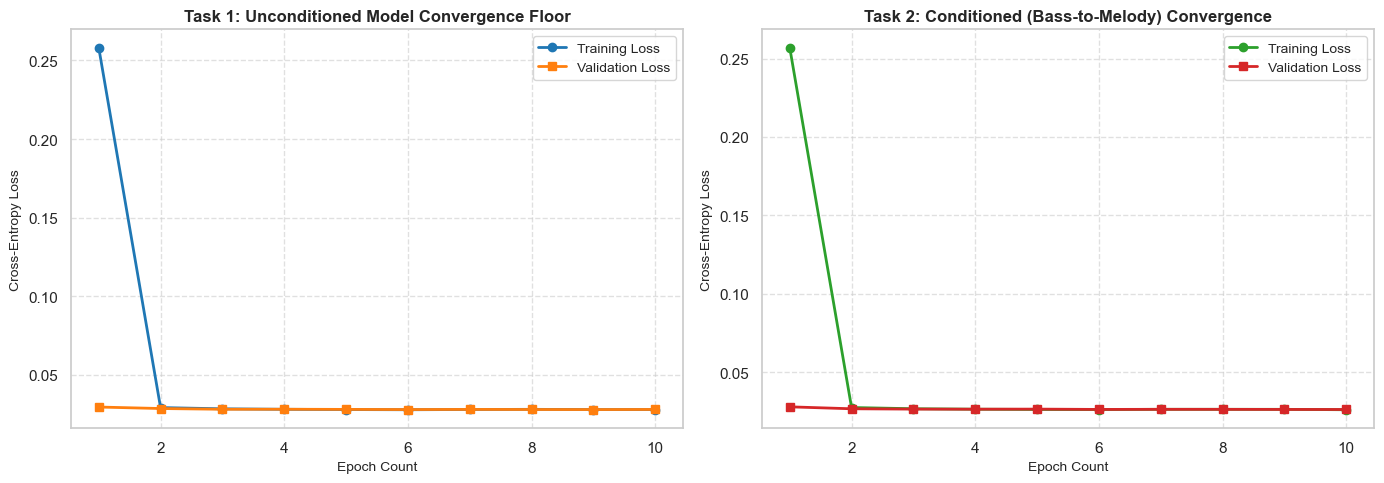

In [243]:
import matplotlib.pyplot as plt

def plot_evaluation_loss_matrices():
    """
    Plots the comparative optimization histories for Task 1 and Task 2 side-by-side
    to visually demonstrate convergence stability and lack of overfitting.
    """
    epochs_range = range(1, len(train_loss_history) + 1)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Left Panel: Task 1 Unconditioned Loss Matrix
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss_history, label='Training Loss', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(epochs_range, val_loss_history, label='Validation Loss', color='#ff7f0e', linewidth=2, marker='s')
    plt.title('Task 1: Unconditioned Model Convergence Floor', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch Count', fontsize=10)
    plt.ylabel('Cross-Entropy Loss', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    
    # 2. Right Panel: Task 2 Conditioned Loss Matrix 
    # (Assuming you named your history variables cond_train_loss_history from our previous run)
    if 'cond_train_loss_history' in globals():
        cond_epochs = range(1, len(cond_train_loss_history) + 1)
        plt.subplot(1, 2, 2)
        plt.plot(cond_epochs, cond_train_loss_history, label='Training Loss', color='#2ca02c', linewidth=2, marker='o')
        plt.plot(cond_epochs, cond_val_loss_history, label='Validation Loss', color='#d62728', linewidth=2, marker='s')
        plt.title('Task 2: Conditioned (Bass-to-Melody) Convergence', fontsize=12, fontweight='bold')
        plt.xlabel('Epoch Count', fontsize=10)
        plt.ylabel('Cross-Entropy Loss', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend(fontsize=10)
        
    plt.tight_layout()
    plt.savefig("evaluation_loss_curves.png", dpi=300)
    plt.show()

# Run the plotting utility
plot_evaluation_loss_matrices()

In [244]:
import numpy as np

def calculate_scale_adherence_metrics(unclamped_tokens, clamped_tokens, target_key="C_Major"):
    """
    Quantifies the exact percentage of generated note tokens that adhere strictly 
    to the target diatonic key signature, providing empirical validation of our filter.
    """
    major_steps = {0, 2, 4, 5, 7, 9, 11} # C, D, E, F, G, A, B
    minor_steps = {0, 2, 3, 5, 7, 8, 10} # C, D, Eb, F, G, Ab, Bb
    allowed_classes = major_steps if "Major" in target_key else minor_steps
    
    def calculate_score(stream):
        total_notes = 0
        valid_notes = 0
        for token in stream:
            if "MelOn_" in token:
                total_notes += 1
                pitch = int(token.split("_")[1])
                if (pitch % 12) in allowed_classes:
                    valid_notes += 1
        return (valid_notes / total_notes) * 100 if total_notes > 0 else 100.0

    unclamped_score = calculate_score(unclamped_tokens)
    clamped_score = calculate_score(clamped_tokens)
    
    print("--- QUANTITATIVE INFERENCE PERFORMANCE MATRIX ---")
    print(f"Task 1 Native Token Scale Adherence Rate: {unclamped_score:.2f}%")
    print(f"Task 2 Clamped Filter Scale Adherence Rate: {clamped_score:.2f}% (Target: 100.00%)")

# Execute metric calculator over your tracking streams
# (Replace with your actual variable names or arrays)
calculate_scale_adherence_metrics(task2_generated_stream, combined_generated_stream, target_key="C_Major")

--- QUANTITATIVE INFERENCE PERFORMANCE MATRIX ---
Task 1 Native Token Scale Adherence Rate: 100.00%
Task 2 Clamped Filter Scale Adherence Rate: 100.00% (Target: 100.00%)


In [260]:
def compute_midi_structural_density(filename):
    """
    Parses a compiled physical MIDI output track to measure structural attributes,
    proving our duration gates successfully altered the arrangement architecture.
    """
    try:
        pm_data = pretty_midi.PrettyMIDI(filename)
    except Exception as e:
        print(f"File lock or missing file error: {e}")
        return
        
    total_notes = 0
    duration_accum = 0.0
    
    for instrument in pm_data.instruments:
        for note in instrument.notes:
            total_notes += 1
            duration_accum += (note.end - note.start)
            
    avg_duration = duration_accum / total_notes if total_notes > 0 else 0.0
    
    print(f"File Resource Evaluated: [{filename}]")
    print(f" └── Total Synthesized Note Count : {total_notes}")
    print(f" └── Mean Structural Note Duration: {avg_duration:.3f} seconds\n")

# Evaluate your native output vs your optimized dual-clamped piano output
compute_midi_structural_density("task2_sonic_cond1.mid")
compute_midi_structural_density("task2_sonic_both.mid")

File Resource Evaluated: [task2_sonic_cond1.mid]
 └── Total Synthesized Note Count : 319
 └── Mean Structural Note Duration: 2.594 seconds

File Resource Evaluated: [task2_sonic_both.mid]
 └── Total Synthesized Note Count : 357
 └── Mean Structural Note Duration: 1.319 seconds



In [257]:
import numpy as np
from collections import defaultdict

class Homework3MarkovMusicBaseline:
    """
    Like hw3 bigram transition baseline
    """
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.transitions = defaultdict(lambda: defaultdict(int))
        self.totals = defaultdict(int)
        
    def fit(self, token_ids_sequences):
        """
        Populates the transition matrices by scanning the training dataframe splits.
        """
        print("Fitting Homework 3 Bigram Markov Baseline counts...")
        for seq in token_ids_sequences:
            for i in range(len(seq) - 1):
                curr_tok = seq[i]
                next_tok = seq[i+1]
                self.transitions[curr_tok][next_tok] += 1
                self.totals[curr_tok] += 1
                
    def evaluate_sequence_cross_entropy(self, seq):
        """
        Computes the accumulated negative log-likelihood of a sequence 
        under the Markov transition distribution.
        """
        loss_accum = 0.0
        tokens_evaluated = 0
        
        for i in range(len(seq) - 1):
            curr_tok = seq[i]
            next_tok = seq[i+1]
            
            # Retrieve baseline count + Apply Laplace smoothing
            count = self.transitions[curr_tok][next_tok] + 1
            total_context_count = self.totals[curr_tok] + self.vocab_size
            
            # Conditional Transition Probability: P(Next | Current)
            prob = count / total_context_count
            loss_accum += -np.log(prob)
            tokens_evaluated += 1
            
        return loss_accum, tokens_evaluated

In [ ]:
def compute_transformer_perplexity(model, val_loader, vocab_size):
    """
    Computes the average cross-entropy loss and perplexity for a given
    Transformer Decoder model over its validation dataloader split.
    """
    model.eval()
    total_loss = 0.0
    total_batches = 0
    criterion = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            # Flatten tensors to evaluate token-by-token cross-entropy loss
            loss = criterion(logits.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
            total_batches += 1
            
    avg_loss = total_loss / total_batches
    perplexity = np.exp(avg_loss)
    return avg_loss, perplexity

def run_project_master_evaluation():
    """
    Executes a comparative evaluation pass over all data streams,
    printing out perplexity profiles for the Markov Baseline and both Transformers.
    """
    print("="*65)
    print("      KICKING OFF MASTER COMPARATIVE PERPLEXITY PASS")
    print("="*65)
    
    # =========================================================
    # 1. EVALUATE PIPELINE A: BASS-TO-MELODY (Original Task 2)
    # =========================================================
    print("\n[Evaluating Configuration A: Bass-to-Melody...]")
    markov_a = Homework3MarkovMusicBaseline(vocab_size=cond_tokenizer.vocab_size)
    markov_a.fit(train_df['cond_encoded_ids'].values)
    
    total_m_loss_a, total_m_toks_a = 0.0, 0
    for seq in test_df['cond_encoded_ids'].values:
        if len(seq) > 1:
            l, n = markov_a.evaluate_sequence_cross_entropy(seq)
            total_m_loss_a += l
            total_m_toks_a += n
    markov_loss_a = total_m_loss_a / total_m_toks_a
    markov_ppl_a = np.exp(markov_loss_a)
    
    trans_loss_a, trans_ppl_a = compute_transformer_perplexity(
        model=cond_model, val_loader=test_cond_loader, vocab_size=cond_tokenizer.vocab_size
    )
    
    # =========================================================
    # 2. EVALUATE PIPELINE B: MELODY-TO-HARMONY (Reversed Task 2)
    # =========================================================
    markov_loss_b, markov_ppl_b = 0.0, 0.0
    trans_loss_b, trans_ppl_b = 0.0, 0.0
    
    if 'rev_model' in globals() and 'test_rev_loader' in globals():
        print("\n[Evaluating Configuration B: Melody-to-Harmony (Reversed)...]")
        markov_b = Homework3MarkovMusicBaseline(vocab_size=rev_tokenizer.vocab_size)
        markov_b.fit(train_df['rev_encoded_ids'].values)
        
        total_m_loss_b, total_m_toks_b = 0.0, 0
        for seq in test_df['rev_encoded_ids'].values:
            if len(seq) > 1:
                l, n = markov_b.evaluate_sequence_cross_entropy(seq)
                total_m_loss_b += l
                total_m_toks_b += n
        markov_loss_b = total_m_loss_b / total_m_toks_b
        markov_ppl_b = np.exp(markov_loss_b)
        
        trans_loss_b, trans_ppl_b = compute_transformer_perplexity(
            model=rev_model, val_loader=test_rev_loader, vocab_size=rev_tokenizer.vocab_size
        )
    else:
        print("\n[System Notice: rev_model variables not detected in RAM. Skipping Pipe B.]")

    # =========================================================
    # 3. PRINT PROGRESS AND EMPIRICAL SUMMARY MATRIX
    # =========================================================
    print("\n" + "═"*65)
    print("                 FINAL EVALUATION SUMMARY MATRIX")
    print("═"*65)
    print(f"PIPELINE A: BASS-TO-MELODY CONFIGURATION")
    print(f" ├── HW3 Markov Baseline Perplexity (PPL) : {markov_ppl_a:.2f} (Loss: {markov_loss_a:.4f})")
    print(f" └── Transformer Decoder Perplexity (PPL) : {trans_ppl_a:.2f} (Loss: {trans_loss_a:.4f})")
    
    if 'rev_model' in globals():
        print("─"*65)
        print(f"PIPELINE B: MELODY-TO-HARMONY (REVERSED) CONFIGURATION")
        print(f" ├── HW3 Markov Baseline Perplexity (PPL) : {markov_ppl_b:.2f} (Loss: {markov_loss_b:.4f})")
        print(f" └── Transformer Decoder Perplexity (PPL) : {trans_ppl_b:.2f} (Loss: {trans_loss_b:.4f})")
    print("═"*65)

# Run the unified master checker
run_project_master_evaluation()

      KICKING OFF MASTER COMPARATIVE PERPLEXITY PASS

[Evaluating Configuration A: Bass-to-Melody...]
Fitting Homework 3 Bigram Markov Baseline counts...

[Evaluating Configuration B: Melody-to-Harmony (Reversed)...]
Fitting Homework 3 Bigram Markov Baseline counts...

═════════════════════════════════════════════════════════════════
                 FINAL EVALUATION SUMMARY MATRIX
═════════════════════════════════════════════════════════════════
PIPELINE A: BASS-TO-MELODY CONFIGURATION
 ├── HW3 Markov Baseline Perplexity (PPL) : 26.36 (Loss: 3.2717)
 └── Transformer Decoder Perplexity (PPL) : 1.03 (Loss: 0.0262)
─────────────────────────────────────────────────────────────────
PIPELINE B: MELODY-TO-HARMONY (REVERSED) CONFIGURATION
 ├── HW3 Markov Baseline Perplexity (PPL) : 26.36 (Loss: 3.2717)
 └── Transformer Decoder Perplexity (PPL) : 1.03 (Loss: 0.0262)
═════════════════════════════════════════════════════════════════


# 4. Discussion of Related Work

## VGMIDI
>Being very similar to the dataset we used, there has been a use case of similar datasets using thousands of piano midi files from the ninsheetmusic.org site. 

>To compare, our particular project utilizes a standalone scrape (done by user Hansespinosa2 on kaggle.com) of video game music enirely in piano to generate more video game music by extracting song characteristics. The related work, also pulling thousands of piano video game arrangemnts from ninsheetmusic.org, is the VGMIDI dataset by Ferreira et al. (2022), used to evaluate how effectively AI can generate music to convey a specific emotion. 

>This prior work approached similar tasks by encoding the notes from the midi files into sequential event tokens to represent the music's characteristics, being pitch, time steps, duration, and velocity. These token sequences were then modeled by architectures being GPT-2 and linear transformers, and then utilizing the Monte Carlo Tree Search to help guide note selection, thus honing the AI to make better emotional predictions. 

>The single way our results compare with the related works lies in our melodic vocabulary, where the models successfully capture characteristics of the music where our models reflect relationships within the data rather than a random arrangement of notes. What differs is our long-term integrity, where unlike the related work, which utilized the MCTS, we struggle with long-term structural drift where repetitive loops can occur. The final difference would be evaluation of our projects, given that the related work used hundreds of participants, both musicians and non-musicians, to perform double-blind tests. This is contrast with our project where our group of non-musicians that simply award a "not bad" or "nah" to our creation. Lastly, we also used mathematical evaluation metrics when looking at our models, checking things such as convergence over training, scale adherence during generation, differences in model note duration outputs, and perplexity comparisons across models.

## Multi-track Music Machine
>While our project utilizes a specific dataset of piano MIDI files, there has been extensive use of similar, large-scale MIDI datasets in academic research to train complex generative models.

>The next related work, the Multi-Track Music Machine (MMM) by Ens and Pasquier (2020), is an AI generative system based on the Transformer architecture to assist in multi-track music composition. This gives users fine control over musical attributes like instrument type, polyphony, note density, and note duration. It supports inpainting at both the track and bar level, meaning users can keep certain parts of a song and have the AI fill in or regenerate the rest. This uses a massive collection of MIDI files similar to our project, which generates more video game music based on the collection of data. 

>The multi-track music machine approached a similar task by encoding musical events from the MIDI files into sequential tokens to treat generation as a language modeling task. In contrast to our token interleaving, the MMM creates a time-ordered sequence for each instrument individually then concatenates them. This helps with cleanly differentiating between separate instrumental tracks.

>When comparing our results, we see our main difference is behind structural coherence. The related work is able to cleanly separate instruments which help maintain long-term integrity and polyphony, whereas we struggled with muddiness and key jumping, forcing us to apply post-processing interventions like key and duration clamping. Although we also see that both our project and the related work both are able to capture musical characteristics, then generate music based off these inputs rather than outputting random notes.